# Results Analysis: Non-Reshuffling Settings

This notebook contains all analyses for the results section of my thesis.

**Structure:**
1. Setup and Data Loading
2. Purely Offline Optimization
3. Purely Online Optimization
4. Hybrid Performance Analysis
5. Algorithm Comparison and Synthesis

## 1. Setup and Data Loading

In [40]:
from pathlib import Path
import json
import re
from datetime import datetime
import numpy as np
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
from scipy import stats

# Science plots styling
plt.style.use('science')
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {"dpi": 200}

# Output directory for figures
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Data directory
BASE_DIR = Path("/u/halle/rsim/home_at/projects/Bachelorarbeit/binpacking/data_analysis/non_reshuffling_settings/param_sweep")

if not BASE_DIR.exists():
    raise FileNotFoundError(f"BASE_DIR not found: {BASE_DIR}")

FILENAME_RE = re.compile(r"^(?P<kind>[^_]+)_(?P<label>.+)_(?P<ts>\d{8}_\d{6})\.json$")

In [41]:
def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def split_family_variant(group: str):
    if not group:
        return None, None
    parts = group.split("_", 1)
    family = parts[0]
    variant = parts[1] if len(parts) > 1 else None
    return family, variant


def parse_sweep_name(name: str) -> dict:
    prefix = name
    off_pct = None
    on_pct = None
    if "_off" in name and "_on" in name:
        prefix, rest = name.split("_off", 1)
        off_str, on_str = rest.split("_on", 1)
        try:
            off_pct = int(off_str)
            on_pct = int(on_str)
        except ValueError:
            off_pct = None
            on_pct = None
    family, variant = split_family_variant(prefix)
    return {
        "sweep": name,
        "sweep_group": prefix,
        "family": family,
        "variant": variant,
        "off_pct": off_pct,
        "on_pct": on_pct,
    }


def parse_filename(path: Path) -> dict:
    m = FILENAME_RE.match(path.name)
    if not m:
        return {"kind": None, "label": None, "run_id": None, "run_dt": None}
    run_id = m.group("ts")
    try:
        run_dt = datetime.strptime(run_id, "%Y%m%d_%H%M%S")
    except ValueError:
        run_dt = None
    return {
        "kind": m.group("kind"),
        "label": m.group("label"),
        "run_id": run_id,
        "run_dt": run_dt,
    }


def split_label(label: str):
    if not label:
        return None, None
    if "+" in label:
        return label.split("+", 1)
    return label, None


def flatten_record(data: dict, path: Path) -> dict:
    agg = data.get("aggregate", {})
    problem = data.get("problem", {})
    rel = path.relative_to(BASE_DIR)
    sweep_meta = parse_sweep_name(rel.parts[0]) if rel.parts else {}
    name_meta = parse_filename(path)
    pipeline = data.get("pipeline") or name_meta.get("label")
    offline_short, online_short = split_label(pipeline)
    return {
        "file": path.name,
        "path": str(path),
        **sweep_meta,
        **name_meta,
        "scenario": data.get("scenario"),
        "scenario_description": data.get("scenario_description"),
        "pipeline": pipeline,
        "offline_solver": data.get("offline_solver"),
        "online_policy": data.get("online_policy"),
        "offline_short": offline_short,
        "online_short": online_short,
        "seed_count": data.get("seed_count"),
        "per_seed": data.get("per_seed"),
        "total_objective_mean": data.get("total_objective_mean", agg.get("total_objective_mean")),
        "offline_objective_mean": agg.get("offline_objective_mean"),
        "online_objective_mean": agg.get("online_objective_mean"),
        "offline_runtime_mean": agg.get("offline_runtime_mean"),
        "online_runtime_mean": agg.get("online_runtime_mean"),
        "runtime_mean": agg.get("runtime_mean"),
        "offline_utilization_mean": agg.get("offline_utilization_mean"),
        "offline_failures": agg.get("offline_failures"),
        "online_failures": agg.get("online_failures"),
        "failures": agg.get("failures"),
        "N": problem.get("N"),
        "M_off": problem.get("M_off"),
        "M_on": problem.get("M_on"),
        "dimensions": problem.get("dimensions"),
    }


def load_results(base_dir: Path = BASE_DIR):
    records = []
    for path in sorted(base_dir.rglob("*.json")):
        records.append(flatten_record(read_json(path), path))
    return records

In [42]:
# Load all results
records = load_results()
print(f"Loaded {len(records)} result files")

Loaded 240 result files


In [43]:
# PHASE 1: CLEANED UP 
df = pd.DataFrame(records)

if df.empty:
    df_eval = None
    df_opt = None
    df_per_seed = None
    print("No records loaded. Check BASE_DIR or records.")
else:
    # Algorithm name mappings 
    offline_map = {
        "cabfd": "CaBfd",
        "util": "UtilDecr",
        "binpacking_milp": "MILP",
        "full_horizon": "Benchmark",
    }
    online_map = {
        "primal_dual": "PrimalDual",
        "sim_dual": "SimDual",  
        "dynamic_learning": "DL",
        "cost_best_fit": "CaBf",
        "rolling_horizon_milp": "RollingMILP",
    }

    def pretty_pipeline(label):
        if not isinstance(label, str) or not label:
            return label
        if "+" in label:
            off_raw, on_raw = (part.strip() for part in label.split("+", 1))
            off_name = offline_map.get(off_raw, off_raw)
            on_name = online_map.get(on_raw, on_raw)
            return f"{off_name} + {on_name}"
        return offline_map.get(label, label)

    df["offline_short_raw"] = df["offline_short"]
    df["online_short_raw"] = df["online_short"]
    df["pipeline_raw"] = df["pipeline"]

    df["offline_short"] = df["offline_short"].map(offline_map).fillna(df["offline_short"])
    df["online_short"] = df["online_short"].map(online_map).fillna(df["online_short"])
    df["pipeline"] = df["pipeline"].apply(pretty_pipeline)

    # Process per-seed data
    df_per_seed = None
    if "per_seed" in df.columns:
        df_seed = df[df["per_seed"].notna()].copy()
        if not df_seed.empty:
            df_seed = df_seed.explode("per_seed").reset_index(drop=True)
            seed_cols = pd.json_normalize(df_seed["per_seed"])
            df_seed = df_seed.drop(columns=["per_seed"]).reset_index(drop=True)
            df_seed = pd.concat([df_seed, seed_cols], axis=1)
            df_seed["offline_short"] = (
                df_seed["offline_short"].map(offline_map).fillna(df_seed["offline_short"])
            )
            df_seed["online_short"] = (
                df_seed["online_short"].map(online_map).fillna(df_seed["online_short"])
            )
            df_seed["pipeline"] = df_seed["pipeline"].apply(pretty_pipeline)
            df_per_seed = df_seed

    df_eval = df[df["kind"] == "eval"].copy()
    df_opt = df[df["kind"] == "optimal"].copy()

print(f"Processed: {len(df_eval)} eval results, {len(df_opt)} optimal benchmarks")
df.head()

Processed: 225 eval results, 15 optimal benchmarks


,file,path,sweep,sweep_group,family,variant,off_pct,on_pct,kind,label,...,offline_failures,online_failures,failures,N,M_off,M_on,dimensions,offline_short_raw,online_short_raw,pipeline_raw
0,eval_binpacking_milp+cost_best_fit_20260125_07...,/u/halle/rsim/home_at/projects/Bachelorarbeit/...,baseline_midvar_off0_on100,baseline_midvar,baseline,midvar,0,100,eval,binpacking_milp+cost_best_fit,...,0.0,14.0,NaN,None,0,200,None,binpacking_milp,cost_best_fit,binpacking_milp+cost_best_fit
1,eval_binpacking_milp+dynamic_learning_20260125...,/u/halle/rsim/home_at/projects/Bachelorarbeit/...,baseline_midvar_off0_on100,baseline_midvar,baseline,midvar,0,100,eval,binpacking_milp+dynamic_learning,...,0.0,10.0,NaN,None,0,200,None,binpacking_milp,dynamic_learning,binpacking_milp+dynamic_learning
2,eval_binpacking_milp+primal_dual_20260125_0744...,/u/halle/rsim/home_at/projects/Bachelorarbeit/...,baseline_midvar_off0_on100,baseline_midvar,baseline,midvar,0,100,eval,binpacking_milp+primal_dual,...,0.0,5.0,NaN,None,0,200,None,binpacking_milp,primal_dual,binpacking_milp+primal_dual
3,eval_binpacking_milp+rolling_horizon_milp_2026...,/u/halle/rsim/home_at/projects/Bachelorarbeit/...,baseline_midvar_off0_on100,baseline_midvar,baseline,midvar,0,100,eval,binpacking_milp+rolling_horizon_milp,...,0.0,18.0,NaN,None,0,200,None,binpacking_milp,rolling_horizon_milp,binpacking_milp+rolling_horizon_milp
4,eval_binpacking_milp+sim_dual_20260125_074420....,/u/halle/rsim/home_at/projects/Bachelorarbeit/...,baseline_midvar_off0_on100,baseline_midvar,baseline,midvar,0,100,eval,binpacking_milp+sim_dual,...,0.0,14.0,NaN,None,0,200,None,binpacking_milp,sim_dual,binpacking_milp+sim_dual


## 2. Purely Offline Optimization

Analyzing offline algorithms (CaBfd, UtilDecr) against MILP benchmark.

**Scenarios:** Varying horizon lengths (M_off ∈ {40, 80, 120, 160})

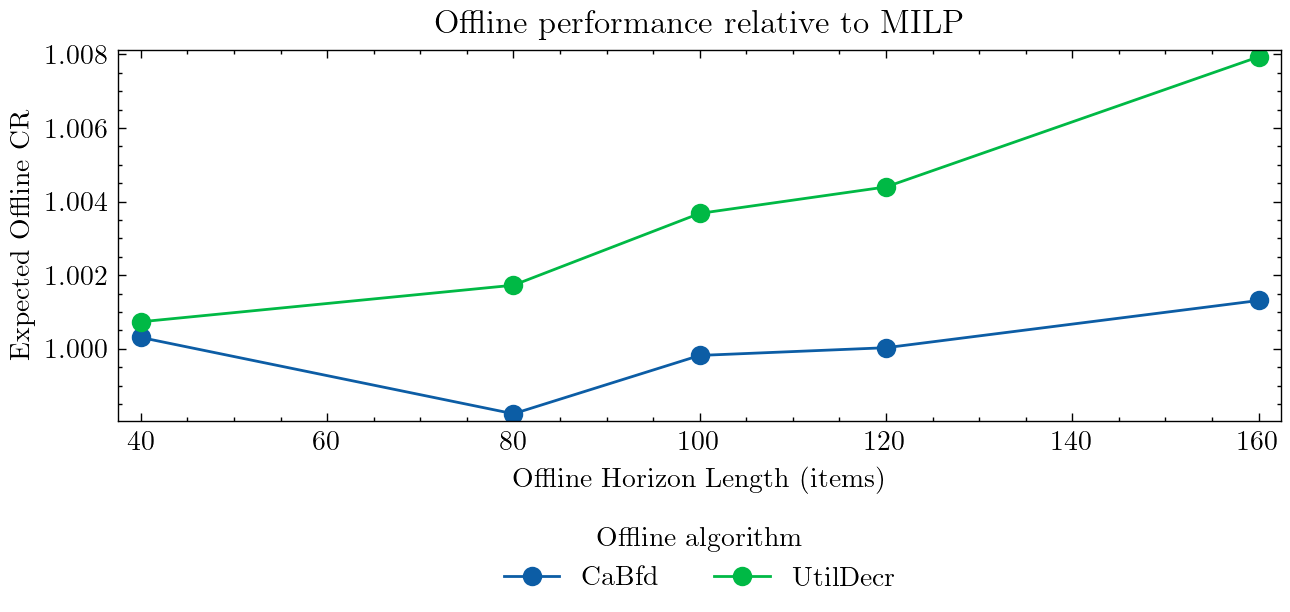

In [44]:
# Competitive Ratio vs. Horizon Length
if df_eval is not None:
    df_offline_plot = df_eval[
        ["M_off", "offline_short", "offline_objective_mean"]
    ].copy()
    df_offline_plot = df_offline_plot[df_offline_plot["M_off"].notna()]
    df_offline_plot = df_offline_plot[df_offline_plot["M_off"].gt(0)]
    df_offline_plot = df_offline_plot[df_offline_plot["offline_objective_mean"].notna()]

    grouped = (
        df_offline_plot.groupby(["M_off", "offline_short"], dropna=False)
        .agg(expected_obj=("offline_objective_mean", "mean"))
        .reset_index()
    )

    df_milp = grouped[grouped["offline_short"] == "MILP"][
        ["M_off", "expected_obj"]
    ].rename(columns={"expected_obj": "milp_obj"})
    df_rel = grouped.merge(df_milp, on="M_off", how="left")
    df_rel = df_rel[df_rel["milp_obj"].notna()]
    df_rel["relative_obj"] = df_rel["expected_obj"] / df_rel["milp_obj"]

    offline_order = ["CaBfd", "UtilDecr"]
    df_rel = df_rel[df_rel["offline_short"].isin(offline_order)]
    df_rel["offline_short"] = pd.Categorical(
        df_rel["offline_short"], categories=offline_order, ordered=True
    )
    df_rel = df_rel.sort_values(["offline_short", "M_off"])

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    for algo in offline_order:
        df_algo = df_rel[df_rel["offline_short"] == algo]
        if df_algo.empty:
            continue
        ax.plot(
            df_algo["M_off"],
            df_algo["relative_obj"],
            marker="o",
            label=algo,
        )

    ax.set_title("Offline performance relative to MILP")
    ax.set_xlabel("Offline Horizon Length (items)")
    ax.set_ylabel("Expected Offline CR")

    y_min = df_rel["relative_obj"].min()
    y_max = df_rel["relative_obj"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    x_min = df_rel["M_off"].min()
    x_max = df_rel["M_off"].max()
    if pd.notna(x_min) and pd.notna(x_max):
        x_pad = 0.02 * (x_max - x_min) if x_max > x_min else 1
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ncol = max(1, df_rel["offline_short"].nunique())
    ax.legend(
        title="Offline algorithm",
        ncol=ncol,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
    )
    fig.subplots_adjust(bottom=0.3)
    fig.savefig(FIG_DIR / "offline_cr_vs_horizon.png", dpi=200, bbox_inches="tight")
    plt.show()

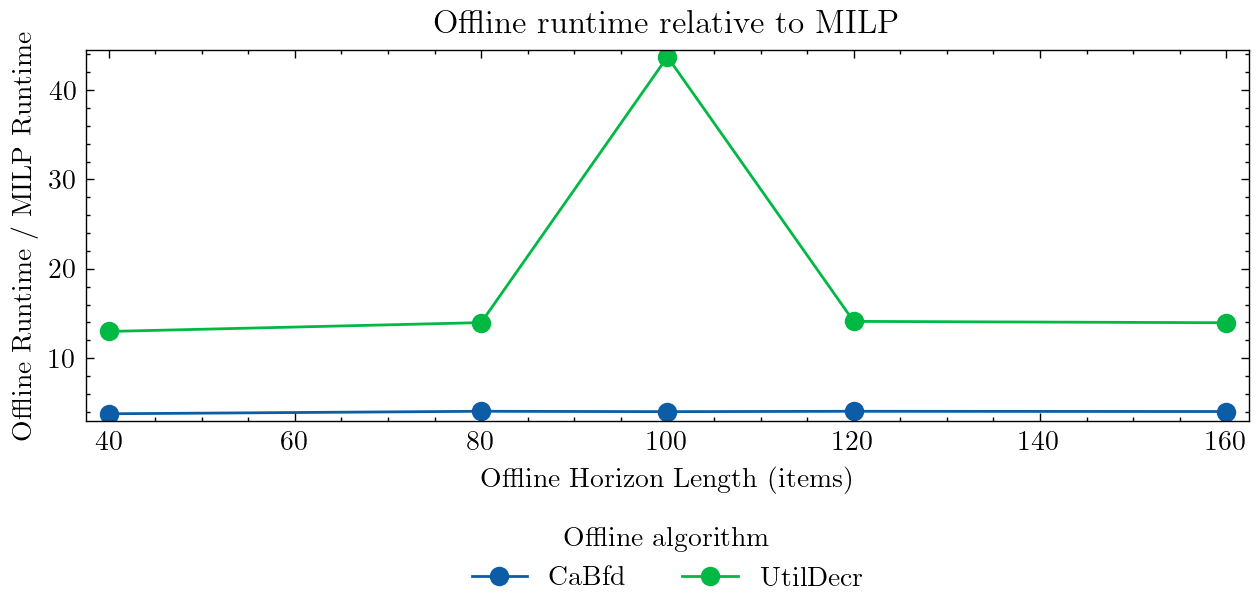

In [45]:
# Runtime vs. Horizon Length
if df_eval is not None:
    df_runtime_plot = df_eval[
        ["M_off", "offline_short", "offline_runtime_mean"]
    ].copy()
    df_runtime_plot = df_runtime_plot[df_runtime_plot["M_off"].notna()]
    df_runtime_plot = df_runtime_plot[df_runtime_plot["M_off"].gt(0)]
    df_runtime_plot = df_runtime_plot[df_runtime_plot["offline_runtime_mean"].notna()]

    grouped = (
        df_runtime_plot.groupby(["M_off", "offline_short"], dropna=False)
        .agg(expected_runtime=("offline_runtime_mean", "mean"))
        .reset_index()
    )

    df_milp = grouped[grouped["offline_short"] == "MILP"][
        ["M_off", "expected_runtime"]
    ].rename(columns={"expected_runtime": "milp_runtime"})
    df_rel = grouped.merge(df_milp, on="M_off", how="left")
    df_rel = df_rel[df_rel["milp_runtime"].notna()]
    df_rel = df_rel[df_rel["milp_runtime"].gt(0)]
    df_rel["relative_runtime"] = df_rel["expected_runtime"] / df_rel["milp_runtime"]

    offline_order = ["CaBfd", "UtilDecr"]
    df_rel = df_rel[df_rel["offline_short"].isin(offline_order)]
    df_rel["offline_short"] = pd.Categorical(
        df_rel["offline_short"], categories=offline_order, ordered=True
    )
    df_rel = df_rel.sort_values(["offline_short", "M_off"])

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    for algo in offline_order:
        df_algo = df_rel[df_rel["offline_short"] == algo]
        if df_algo.empty:
            continue
        ax.plot(
            df_algo["M_off"],
            df_algo["relative_runtime"],
            marker="o",
            label=algo,
        )

    ax.set_title("Offline runtime relative to MILP")
    ax.set_xlabel("Offline Horizon Length (items)")
    ax.set_ylabel("Offline Runtime / MILP Runtime")

    y_min = df_rel["relative_runtime"].min()
    y_max = df_rel["relative_runtime"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    x_min = df_rel["M_off"].min()
    x_max = df_rel["M_off"].max()
    if pd.notna(x_min) and pd.notna(x_max):
        x_pad = 0.02 * (x_max - x_min) if x_max > x_min else 1
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ncol = max(1, df_rel["offline_short"].nunique())
    ax.legend(
        title="Offline algorithm",
        ncol=ncol,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
    )
    fig.subplots_adjust(bottom=0.3)
    fig.savefig(FIG_DIR / "offline_runtime_vs_horizon.png", dpi=200, bbox_inches="tight")
    plt.show()

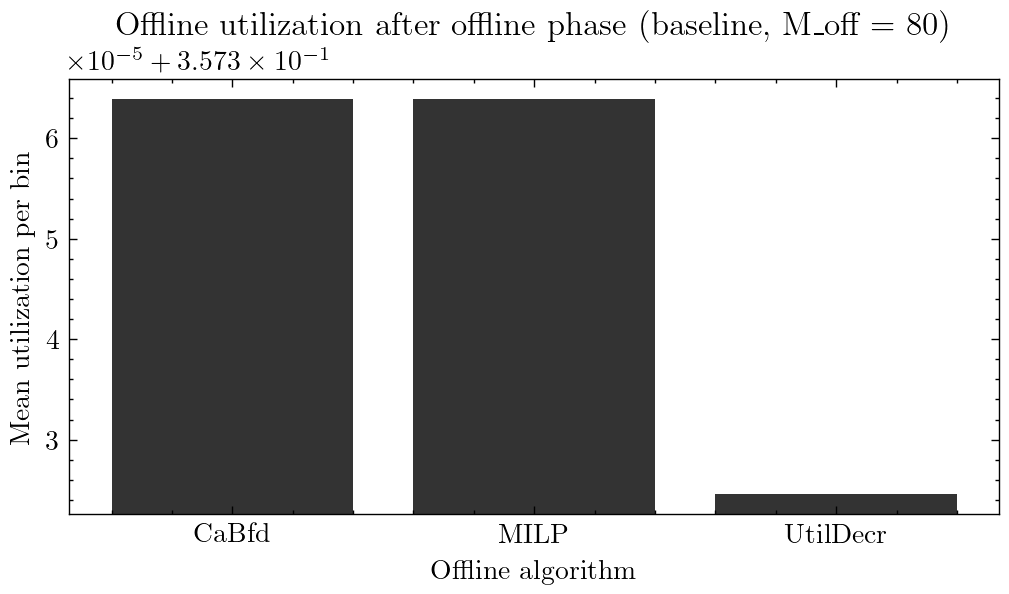

In [46]:
# Offline utilization after offline phase (baseline, M_off = 80)
if df_eval is not None:
    df_util_plot = df_eval[["family", "M_off", "offline_short", "offline_utilization_mean"]].copy()
    df_util_plot = df_util_plot[df_util_plot["family"] == "baseline"]
    df_util_plot = df_util_plot[df_util_plot["offline_utilization_mean"].notna()]
    df_util_plot = df_util_plot[df_util_plot["M_off"] == 80]

    if df_util_plot.empty:
        print("No offline utilization data for baseline with M_off = 80.")
    else:
        grouped = (
            df_util_plot.groupby("offline_short", dropna=False)
            .agg(util_mean=("offline_utilization_mean", "mean"))
            .reset_index()
        )

        offline_order = ["CaBfd", "MILP", "UtilDecr"]
        grouped["offline_short"] = pd.Categorical(
            grouped["offline_short"], categories=offline_order, ordered=True
        )
        grouped = grouped.sort_values("offline_short").dropna(subset=["offline_short"])

        fig, ax = plt.subplots(figsize=(6.0, 3.2))
        positions = np.arange(len(grouped))
        ax.bar(positions, grouped["util_mean"], color="black", alpha=0.8)

        ax.set_title("Offline utilization after offline phase (baseline, M_off = 80)")
        ax.set_xlabel("Offline algorithm")
        ax.set_ylabel("Mean utilization per bin")
        ax.set_xticks(positions)
        ax.set_xticklabels(grouped["offline_short"])

        y_min = grouped["util_mean"].min()
        y_max = grouped["util_mean"].max()
        if pd.isna(y_min) or pd.isna(y_max):
            y_min, y_max = 0.0, 1.0
        y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.05
        ax.set_ylim(max(0.0, y_min - y_pad), y_max + y_pad)

        fig.subplots_adjust(bottom=0.2)
        fig.savefig(FIG_DIR / "offline_utilization_moff80.png", dpi=200, bbox_inches="tight")
        plt.show()


## 3. Purely Online Optimization

Analyzing online algorithms without offline buffer capacity.

**Scenario:** baseline_midvar_off0_on100  
**Algorithms:** CaBf, RollingMILP, DL, SimDual, PrimalDual

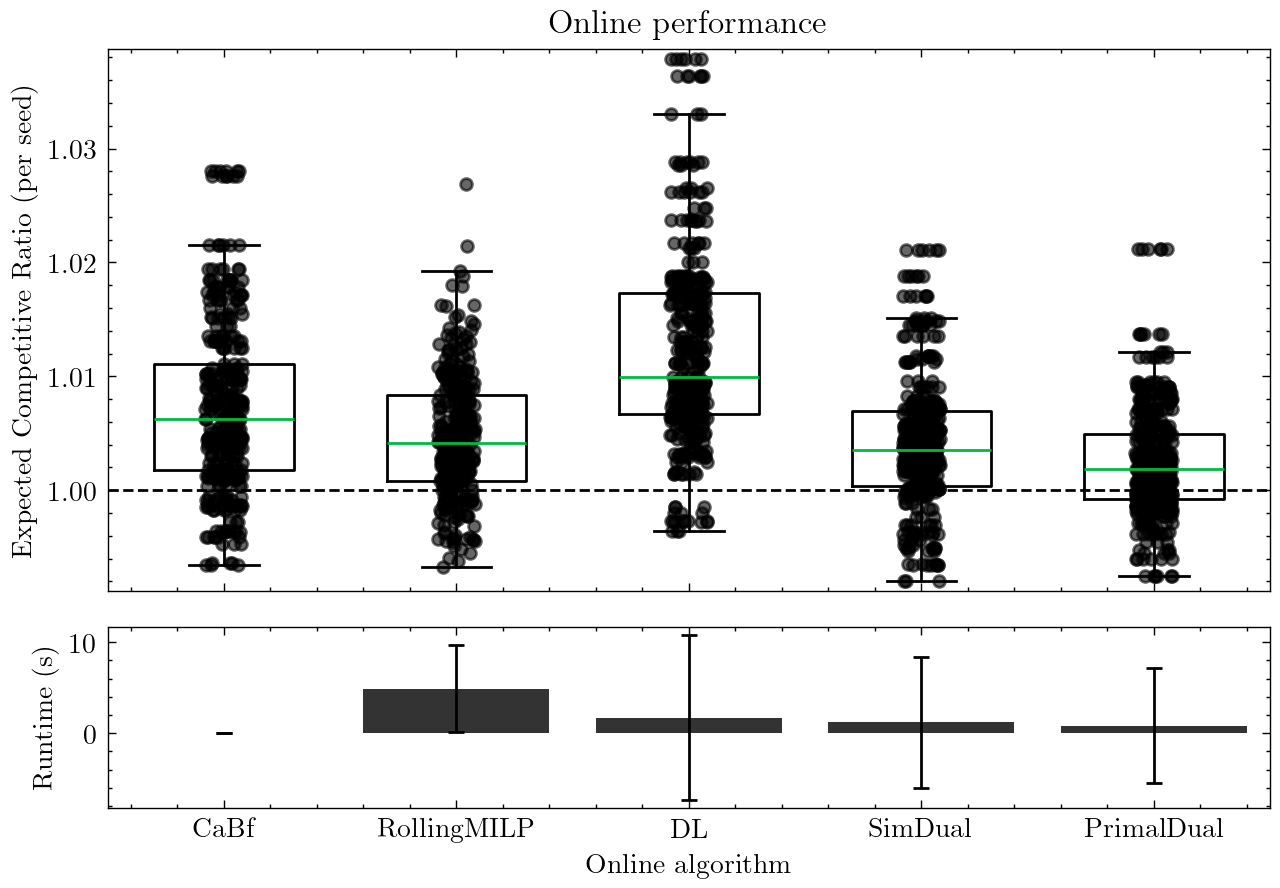

In [47]:
# PHASE 1: CLEANED - NO SIMBASE IN online_order
# Competitive Ratio Distribution
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    df_online_all = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    df_online_success = df_online_all[
        ~df_online_all["offline_status"].isin(offline_fail_statuses)
        & ~df_online_all["online_status"].isin(online_fail_statuses)
    ].copy()

    df_opt_all = df_per_seed[(df_per_seed["kind"] == "optimal") & (df_per_seed["M_off"] == 0)].copy()
    df_opt_success = df_opt_all[~df_opt_all["status"].isin(offline_fail_statuses)].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    df_join = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_join = df_join[df_join["optimal_objective"].notna()]
    df_join = df_join[df_join["online_objective"].notna()]
    df_join["competitive_ratio"] = df_join["online_objective"] / df_join["optimal_objective"]

    # NO SIMBASE
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
    df_join["online_short"] = pd.Categorical(
        df_join["online_short"], categories=online_order, ordered=True
    )
    df_join = df_join.sort_values(["online_short", "seed"])

    data = []
    labels = []
    for algo in online_order:
        vals = df_join[df_join["online_short"] == algo]["competitive_ratio"].dropna().values
        if len(vals) == 0:
            continue
        data.append(vals)
        labels.append(algo)

    if data:
        runtime_stats = None
        if not df_online_all.empty and "online_runtime" in df_online_all.columns:
            runtime_stats = (
                df_online_all.groupby("online_short")["online_runtime"]
                .agg(mean_runtime="mean", std_runtime="std")
            )

        fig, (ax_box, ax_runtime) = plt.subplots(
            2, 1, figsize=(7.5, 5.2), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
        )
        positions = np.arange(1, len(labels) + 1)
        ax_box.boxplot(data, positions=positions, widths=0.6, showfliers=False)

        rng = np.random.default_rng(0)
        for pos, vals in zip(positions, data):
            jitter = rng.uniform(-0.08, 0.08, size=len(vals))
            ax_box.scatter(pos + jitter, vals, s=18, alpha=0.6, color="black")

        ax_box.axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_box.set_title("Online performance")
        ax_box.set_ylabel("Expected Competitive Ratio (per seed)")
        ax_box.tick_params(axis="x", labelbottom=False)

        y_min = df_join["competitive_ratio"].min()
        y_max = df_join["competitive_ratio"].max()
        if pd.isna(y_min) or pd.isna(y_max):
            y_min, y_max = 0.0, 1.0
        y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
        ax_box.set_ylim(y_min - y_pad, y_max + y_pad)

        mean_runtimes = [0.0] * len(labels)
        std_runtimes = [0.0] * len(labels)
        if runtime_stats is not None:
            for i, algo in enumerate(labels):
                if algo in runtime_stats.index:
                    mean_runtimes[i] = float(runtime_stats.loc[algo, "mean_runtime"])
                    std_runtimes[i] = float(runtime_stats.loc[algo, "std_runtime"]) if not pd.isna(runtime_stats.loc[algo, "std_runtime"]) else 0.0

        ax_runtime.bar(positions, mean_runtimes, color="black", alpha=0.8)
        ax_runtime.errorbar(positions, mean_runtimes, yerr=std_runtimes,
                           fmt='none', ecolor='black', capsize=3)
        ax_runtime.set_ylabel("Runtime (s)")
        ax_runtime.set_xlabel("Online algorithm")
        ax_runtime.set_xticks(positions)
        ax_runtime.set_xticklabels(labels)

        fig.subplots_adjust(hspace=0.1, bottom=0.15)
        fig.savefig(FIG_DIR / "online_cr_distribution.png", dpi=200, bbox_inches="tight")
        plt.show()


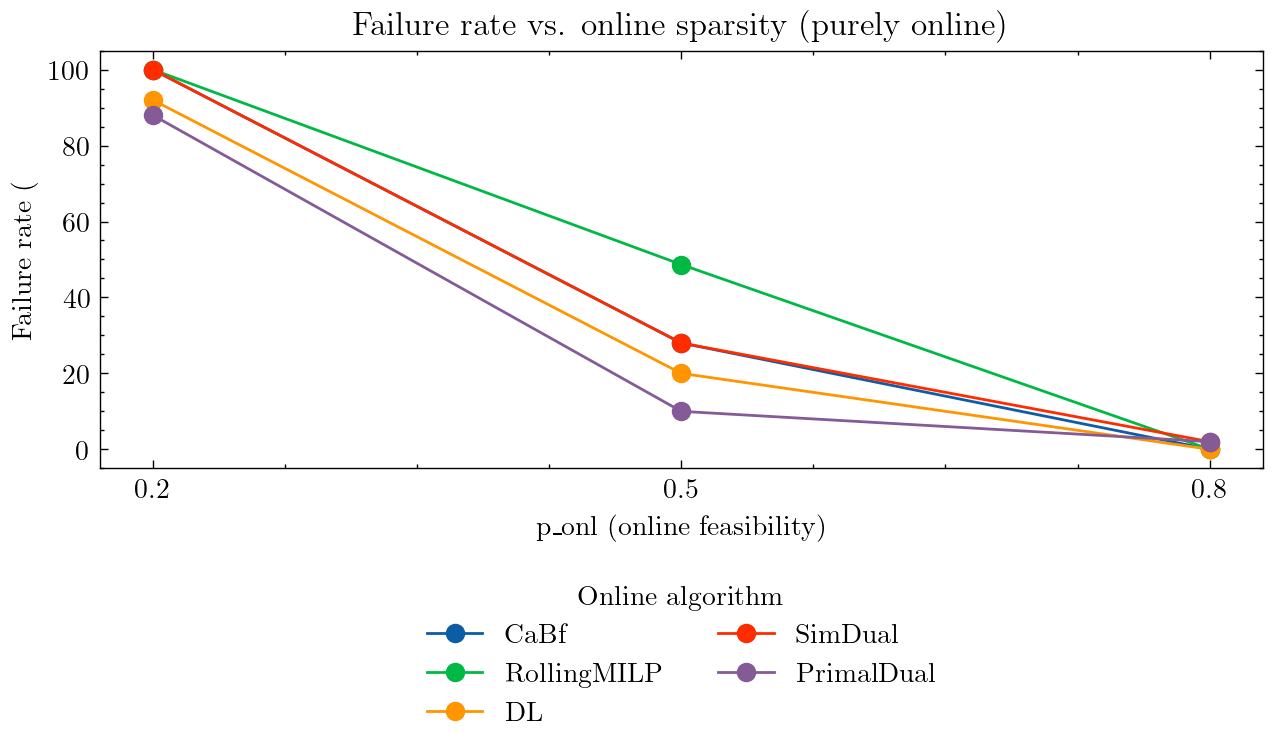

In [48]:
# Failure rates vs. online sparsity (p_onl) for purely online setting
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    scenario_p_onl = {
        "graph_dense_off0_on100": 0.8,
        "graph_mid_off0_on100": 0.5,
        "graph_sparse_off0_on100": 0.2,
    }

    df_graph = df_per_seed[
        (df_per_seed["kind"] == "eval")
        & (df_per_seed["M_off"] == 0)
        & (df_per_seed["scenario"].isin(scenario_p_onl))
    ].copy()

    if df_graph.empty:
        print("No graph sparsity scenarios found for off0_on100. Did you run family 3b?")
    else:
        df_graph["p_onl"] = df_graph["scenario"].map(scenario_p_onl)
        df_graph["failed"] = (
            df_graph["offline_status"].isin(offline_fail_statuses)
            | df_graph["online_status"].isin(online_fail_statuses)
        )

        online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
        df_graph = df_graph[df_graph["online_short"].isin(online_order)]

        grouped = (
            df_graph.groupby(["p_onl", "online_short"], dropna=False)["failed"]
            .mean()
            .reset_index()
            .sort_values(["online_short", "p_onl"])
        )

        fig, ax = plt.subplots(figsize=(7.5, 3.6))
        for algo in online_order:
            df_algo = grouped[grouped["online_short"] == algo]
            if df_algo.empty:
                continue
            ax.plot(
                df_algo["p_onl"],
                df_algo["failed"] * 100.0,
                marker="o",
                label=algo,
            )

        ax.set_title("Failure rate vs. online sparsity (purely online)")
        ax.set_xlabel("p_onl (online feasibility)")
        ax.set_ylabel("Failure rate (%)")
        ax.set_xticks(sorted(scenario_p_onl.values()))
        ax.legend(title="Online algorithm", ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
        fig.subplots_adjust(bottom=0.3)
        fig.savefig(FIG_DIR / "online_failure_rate_vs_ponl.png", dpi=200, bbox_inches="tight")
        plt.show()


In [49]:
# Detailed Failure Analysis
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    df_online_seed = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    if not df_online_seed.empty:
        df_online_seed["failed"] = (
            df_online_seed["offline_status"].isin(offline_fail_statuses)
            | df_online_seed["online_status"].isin(online_fail_statuses)
        )

        status_counts = (
            df_online_seed.groupby(["online_short", "online_status"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values(["online_short", "count"], ascending=[True, False])
        )
        print("\nStatus Counts by Algorithm:")
        display(status_counts)

        failure_rates = (
            df_online_seed.groupby("online_short")["failed"]
            .agg(fail_rate="mean", total_runs="size")
            .reset_index()
            .sort_values("fail_rate", ascending=False)
        )
        print("\nFailure Rates:")
        display(failure_rates)

        scenario_failures = (
            df_online_seed[df_online_seed["failed"]]
            .groupby(["online_short", "scenario"], dropna=False)
            .size()
            .reset_index(name="fail_count")
            .sort_values("fail_count", ascending=False)
        )
        print("\nTop Failure Scenarios:")
        display(scenario_failures.head(20))


Status Counts by Algorithm:


,online_short,online_status,count
0,CaBf,COMPLETED,366
1,CaBf,INFEASIBLE,234
2,DL,COMPLETED,402
3,DL,INFEASIBLE,198
4,PrimalDual,COMPLETED,435
5,PrimalDual,INFEASIBLE,165
6,RollingMILP,COMPLETED,310
7,RollingMILP,INFEASIBLE,290
8,SimDual,COMPLETED,363
9,SimDual,INFEASIBLE,237



Failure Rates:


,online_short,fail_rate,total_runs
3,RollingMILP,0.483333,600
4,SimDual,0.395000,600
0,CaBf,0.390000,600
1,DL,0.330000,600
2,PrimalDual,0.275000,600



Top Failure Scenarios:


,online_short,scenario,fail_count
2,CaBf,graph_sparse_off0_on100,150
16,SimDual,graph_sparse_off0_on100,150
12,RollingMILP,graph_sparse_off0_on100,150
5,DL,graph_sparse_off0_on100,138
9,PrimalDual,graph_sparse_off0_on100,132
11,RollingMILP,graph_mid_off0_on100,73
10,RollingMILP,baseline_midvar_off0_on100,67
0,CaBf,baseline_midvar_off0_on100,42
1,CaBf,graph_mid_off0_on100,42
15,SimDual,graph_mid_off0_on100,42


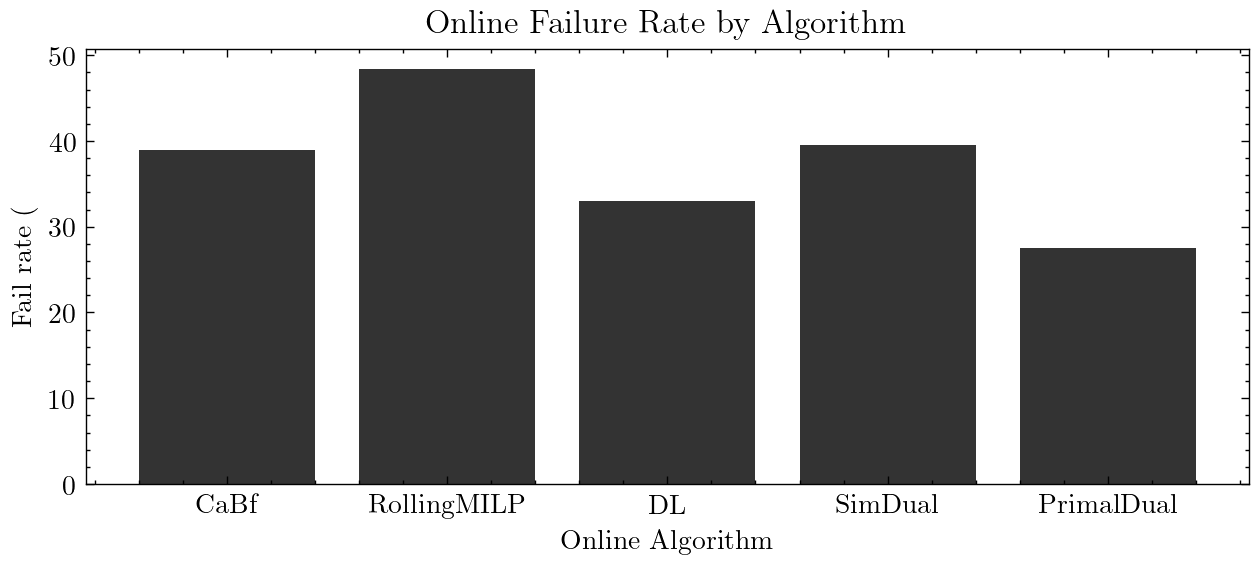

Online Failure Rate Statistics:


,online_short,fail_rate,total_runs
0,CaBf,0.390000,600
3,RollingMILP,0.483333,600
1,DL,0.330000,600
4,SimDual,0.395000,600
2,PrimalDual,0.275000,600


In [50]:
# PHASE 3: Online Failure Rate Analysis
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    df_online_seed = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    if not df_online_seed.empty:
        df_online_seed["failed"] = (
            df_online_seed["offline_status"].isin(offline_fail_statuses)
            | df_online_seed["online_status"].isin(online_fail_statuses)
        )

        grouped = (
            df_online_seed.groupby("online_short", dropna=False)
            .agg(fail_rate=("failed", "mean"), total_runs=("failed", "size"))
            .reset_index()
        )

        online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
        grouped["online_short"] = pd.Categorical(
            grouped["online_short"], categories=online_order, ordered=True
        )
        grouped = grouped.sort_values("online_short").dropna(subset=["online_short"])

        if not grouped.empty:
            fig, ax = plt.subplots(figsize=(7.5, 3.2))
            positions = np.arange(len(grouped))

            ax.bar(positions, grouped["fail_rate"] * 100.0, color="black", alpha=0.8)
            ax.set_title("Online Failure Rate by Algorithm")
            ax.set_xlabel("Online Algorithm")
            ax.set_ylabel("Fail rate (%)")
            ax.set_xticks(positions)
            ax.set_xticklabels(grouped["online_short"])

            fig.subplots_adjust(bottom=0.2)
            fig.savefig(FIG_DIR / "online_failure_rate.png", dpi=200, bbox_inches="tight")
            plt.show()

            print("Online Failure Rate Statistics:")
            display(grouped)


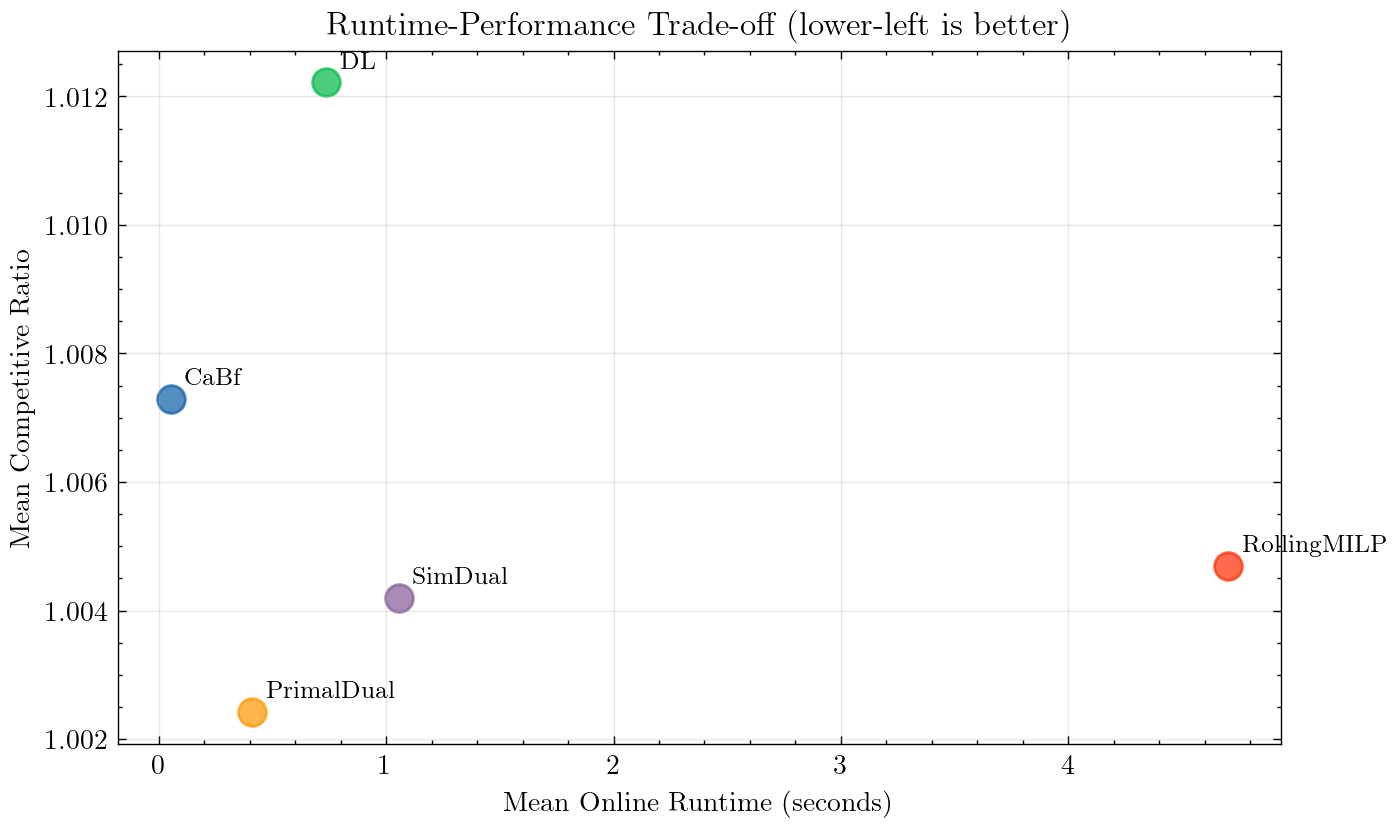


Runtime vs. Performance:


,online_short,mean_cr,mean_runtime,std_cr,std_runtime
2,PrimalDual,1.002415,0.411385,0.004807,3.998481
4,SimDual,1.004196,1.057374,0.005984,6.576990
3,RollingMILP,1.004696,4.702721,0.005446,4.557375
0,CaBf,1.007291,0.055280,0.007524,0.005482
1,DL,1.012218,0.737663,0.008505,5.077583


In [51]:
# Runtime vs. Performance Trade-off
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    # Get purely online data (M_off = 0)
    df_online_only = df_per_seed[
        (df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)
    ].copy()

    df_online_success = df_online_only[
        ~df_online_only["offline_status"].isin(offline_fail_statuses)
        & ~df_online_only["online_status"].isin(online_fail_statuses)
    ].copy()

    # Get optimal benchmarks
    df_opt_only = df_per_seed[
        (df_per_seed["kind"] == "optimal") & (df_per_seed["M_off"] == 0)
    ].copy()
    df_opt_success = df_opt_only[
        ~df_opt_only["status"].isin(offline_fail_statuses)
    ].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    # Merge and compute CR
    df_perf = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_perf = df_perf[df_perf["optimal_objective"].notna()]
    df_perf = df_perf[df_perf["online_objective"].notna()]
    df_perf["competitive_ratio"] = df_perf["online_objective"] / df_perf["optimal_objective"]

    # Aggregate by algorithm
    agg_perf = df_perf.groupby("online_short", dropna=False).agg(
        mean_cr=("competitive_ratio", "mean"),
        mean_runtime=("online_runtime", "mean"),
        std_cr=("competitive_ratio", "std"),
        std_runtime=("online_runtime", "std"),
    ).reset_index()

    # NO SIMBASE
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
    agg_perf = agg_perf[agg_perf["online_short"].isin(online_order)]

    if not agg_perf.empty:
        fig, ax = plt.subplots(figsize=(7.5, 4.5))

        for _, row in agg_perf.iterrows():
            ax.scatter(row["mean_runtime"], row["mean_cr"], s=100, alpha=0.7)
            ax.annotate(
                row["online_short"],
                (row["mean_runtime"], row["mean_cr"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=9,
            )

        ax.set_xlabel("Mean Online Runtime (seconds)")
        ax.set_ylabel("Mean Competitive Ratio")
        ax.set_title("Runtime-Performance Trade-off (lower-left is better)")
        ax.grid(True, alpha=0.3)

        fig.savefig(FIG_DIR / "runtime_vs_performance.png", dpi=200, bbox_inches="tight")
        plt.show()

        print("\nRuntime vs. Performance:")
        display(agg_perf.sort_values("mean_cr"))

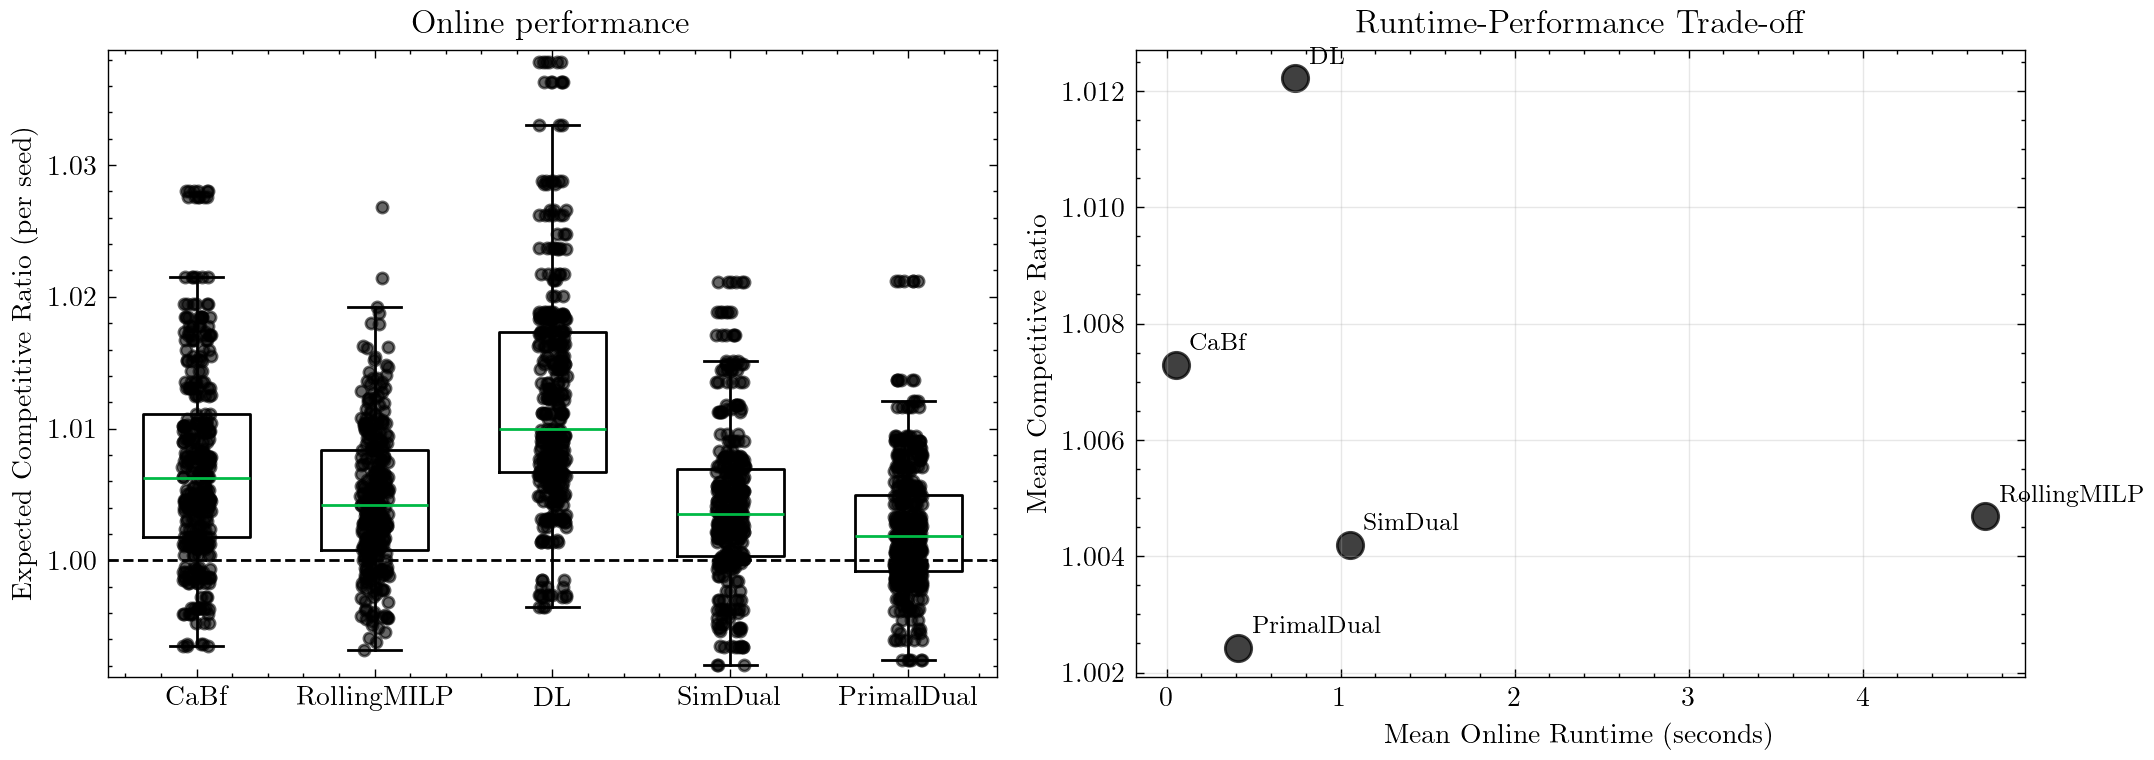

In [52]:
# Combined view: Competitive Ratio Distribution + Runtime-Performance Trade-off
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    # Purely online data
    df_online_all = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    df_online_success = df_online_all[
        ~df_online_all["offline_status"].isin(offline_fail_statuses)
        & ~df_online_all["online_status"].isin(online_fail_statuses)
    ].copy()

    df_opt_all = df_per_seed[(df_per_seed["kind"] == "optimal") & (df_per_seed["M_off"] == 0)].copy()
    df_opt_success = df_opt_all[~df_opt_all["status"].isin(offline_fail_statuses)].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    df_join = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_join = df_join[df_join["optimal_objective"].notna()]
    df_join = df_join[df_join["online_objective"].notna()]
    df_join["competitive_ratio"] = df_join["online_objective"] / df_join["optimal_objective"]

    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
    df_join["online_short"] = pd.Categorical(
        df_join["online_short"], categories=online_order, ordered=True
    )
    df_join = df_join.sort_values(["online_short", "seed"])

    data = []
    labels = []
    for algo in online_order:
        vals = df_join[df_join["online_short"] == algo]["competitive_ratio"].dropna().values
        if len(vals) == 0:
            continue
        data.append(vals)
        labels.append(algo)

    # Runtime-performance aggregation
    df_perf = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_perf = df_perf[df_perf["optimal_objective"].notna()]
    df_perf = df_perf[df_perf["online_objective"].notna()]
    df_perf["competitive_ratio"] = df_perf["online_objective"] / df_perf["optimal_objective"]

    agg_perf = df_perf.groupby("online_short", dropna=False).agg(
        mean_cr=("competitive_ratio", "mean"),
        mean_runtime=("online_runtime", "mean"),
    ).reset_index()
    agg_perf = agg_perf[agg_perf["online_short"].isin(online_order)]

    if data and not agg_perf.empty:
        fig, (ax_box, ax_scatter) = plt.subplots(1, 2, figsize=(11.0, 4.0))

        # Left: competitive ratio distribution
        positions = np.arange(1, len(labels) + 1)
        ax_box.boxplot(data, positions=positions, widths=0.6, showfliers=False)
        rng = np.random.default_rng(0)
        for pos, vals in zip(positions, data):
            jitter = rng.uniform(-0.08, 0.08, size=len(vals))
            ax_box.scatter(pos + jitter, vals, s=16, alpha=0.6, color="black")
        ax_box.axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_box.set_title("Online performance")
        ax_box.set_ylabel("Expected Competitive Ratio (per seed)")
        ax_box.set_xticks(positions)
        ax_box.set_xticklabels(labels, rotation=0)

        y_min = df_join["competitive_ratio"].min()
        y_max = df_join["competitive_ratio"].max()
        if pd.isna(y_min) or pd.isna(y_max):
            y_min, y_max = 0.0, 1.0
        y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
        ax_box.set_ylim(y_min - y_pad, y_max + y_pad)

        # Right: runtime vs performance
        for _, row in agg_perf.iterrows():
            ax_scatter.scatter(row["mean_runtime"], row["mean_cr"], s=90, alpha=0.75, color="black")
            ax_scatter.annotate(
                row["online_short"],
                (row["mean_runtime"], row["mean_cr"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=9,
            )

        ax_scatter.set_xlabel("Mean Online Runtime (seconds)")
        ax_scatter.set_ylabel("Mean Competitive Ratio")
        ax_scatter.set_title("Runtime-Performance Trade-off")
        ax_scatter.grid(True, alpha=0.3)

        fig.tight_layout()
        fig.savefig(FIG_DIR / "online_perf_runtime_combined.png", dpi=200, bbox_inches="tight")
        plt.show()


## 4. Hybrid Performance Analysis\n\nAnalyzing pipelines across varying offline/online splits and comparing failure rates.

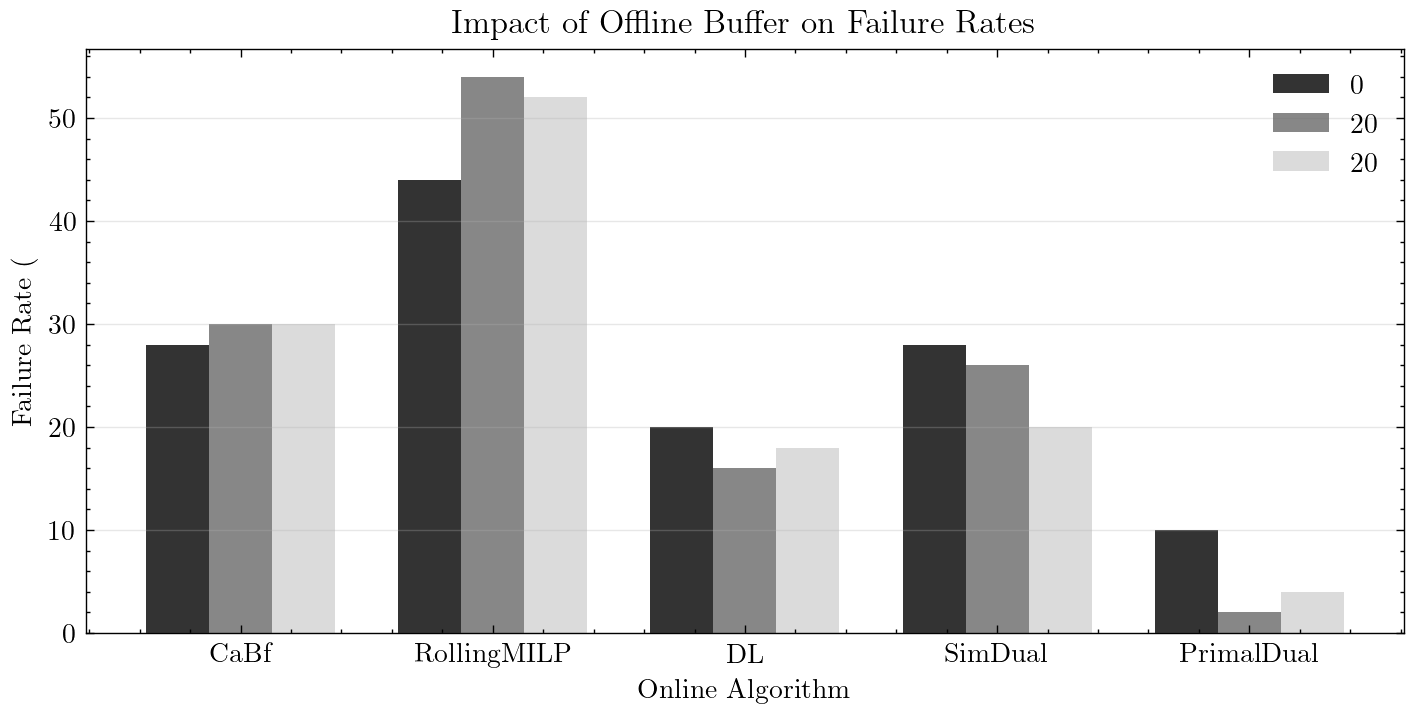


Failure Rate Reduction (0% → 20% offline):


,Algorithm,0% Offline,20% MILP,20% UtilDecr,Reduction (MILP),Reduction (UtilDecr)
online_short,,,,,,
CaBf,CaBf,28.0,30.0,30.0,-2.0,-2.0
RollingMILP,RollingMILP,44.0,54.0,52.0,-10.0,-8.0
DL,DL,20.0,16.0,18.0,4.0,2.0
SimDual,SimDual,28.0,26.0,20.0,2.0,8.0
PrimalDual,PrimalDual,10.0,2.0,4.0,8.0,6.0


In [53]:
# PHASE 4: Failure Rate Comparison - 0% vs 20% Offline (MILP vs UtilDecr)
if df_eval is not None and df_opt is not None:
    df_opt_key = df_opt[["sweep", "run_id", "scenario", "total_objective_mean"]].rename(
        columns={"total_objective_mean": "optimal_objective_mean"}
    )
    df_ratio_base_all = df_eval.merge(df_opt_key, on=["sweep", "run_id", "scenario"], how="left")

    df_baseline = df_ratio_base_all[df_ratio_base_all["family"] == "baseline"].copy()

    denom = df_baseline["M_off"].fillna(0) + df_baseline["M_on"].fillna(0)
    df_baseline["offline_pct"] = (
        (df_baseline["M_off"] / denom) * 100
    ).where(denom > 0)

    df_baseline["total_failures"] = (
        df_baseline["offline_failures"].fillna(0) + df_baseline["online_failures"].fillna(0)
    )
    df_baseline["seed_count"] = df_baseline["seed_count"].fillna(0)

    # Filter to 0% and 20% offline
    df_comparison = df_baseline[df_baseline["offline_pct"].isin([0, 20])].copy()

    # Group by offline_pct, offline_short, AND online_short
    grouped = (
        df_comparison.groupby(["offline_pct", "offline_short", "online_short"], dropna=False)
        .agg(
            failure_count=("total_failures", "sum"),
            seed_count=("seed_count", "sum"),
        )
        .reset_index()
    )

    grouped["failure_rate"] = grouped["failure_count"] / grouped["seed_count"].replace({0: pd.NA})

    # NO SIMBASE
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
    grouped = grouped[grouped["online_short"].isin(online_order)]

    # For 0% offline, all offline_short values are the same (no offline items)
    # So we just take the first one for each online algorithm
    df_0pct = grouped[grouped["offline_pct"] == 0].groupby("online_short").first().reset_index()
    df_0pct = df_0pct[["online_short", "failure_rate"]].rename(columns={"failure_rate": "0pct"})

    # For 20% offline, separate by offline solver
    df_20pct_milp = grouped[(grouped["offline_pct"] == 20) & (grouped["offline_short"] == "MILP")]
    df_20pct_milp = df_20pct_milp[["online_short", "failure_rate"]].rename(columns={"failure_rate": "20pct_milp"})

    df_20pct_util = grouped[(grouped["offline_pct"] == 20) & (grouped["offline_short"] == "UtilDecr")]
    df_20pct_util = df_20pct_util[["online_short", "failure_rate"]].rename(columns={"failure_rate": "20pct_util"})

    # Merge all three
    pivot = df_0pct.merge(df_20pct_milp, on="online_short", how="outer")
    pivot = pivot.merge(df_20pct_util, on="online_short", how="outer")
    pivot = pivot.set_index("online_short").reindex(online_order)

    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(8.5, 4.0))

        x = np.arange(len(pivot))
        width = 0.25

        # Three bars per algorithm
        ax.bar(x - width, pivot["0pct"] * 100, width,
               label="0% Offline (Pure Online)", color="black", alpha=0.8)
        ax.bar(x, pivot["20pct_milp"] * 100, width,
               label="20% Offline (MILP)", color="dimgray", alpha=0.8)
        ax.bar(x + width, pivot["20pct_util"] * 100, width,
               label="20% Offline (UtilDecr)", color="lightgray", alpha=0.8)

        ax.set_ylabel("Failure Rate (%)")
        ax.set_xlabel("Online Algorithm")
        ax.set_title("Impact of Offline Buffer on Failure Rates")
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index)
        ax.legend()
        ax.grid(True, axis='y', alpha=0.3)

        fig.subplots_adjust(bottom=0.15)
        fig.savefig(FIG_DIR / "failure_comparison_0vs20.png", dpi=200, bbox_inches="tight")
        plt.show()

        print("\nFailure Rate Reduction (0% → 20% offline):")
        reduction = pd.DataFrame({
            "Algorithm": pivot.index,
            "0% Offline": (pivot["0pct"] * 100).round(1),
            "20% MILP": (pivot["20pct_milp"] * 100).round(1),
            "20% UtilDecr": (pivot["20pct_util"] * 100).round(1),
            "Reduction (MILP)": ((pivot["0pct"] - pivot["20pct_milp"]) * 100).round(1),
            "Reduction (UtilDecr)": ((pivot["0pct"] - pivot["20pct_util"]) * 100).round(1),
        })
        display(reduction)

In [54]:
# Compute expected CR table for hybrid scenarios
if df_eval is not None and df_opt is not None:
    df_opt_key = df_opt[["sweep", "run_id", "scenario", "total_objective_mean"]].rename(
        columns={"total_objective_mean": "optimal_objective_mean"}
    )
    df_ratio_base_all = df_eval.merge(df_opt_key, on=["sweep", "run_id", "scenario"], how="left")
    df_ratio_base_all = df_ratio_base_all.copy()
    df_ratio_base_all["competitive_ratio"] = (
        df_ratio_base_all["total_objective_mean"] / df_ratio_base_all["optimal_objective_mean"]
    )

    df_baseline = df_ratio_base_all[df_ratio_base_all["family"] == "baseline"].copy()

    denom = df_baseline["M_off"].fillna(0) + df_baseline["M_on"].fillna(0)
    df_baseline["offline_pct"] = (
        (df_baseline["M_off"] / denom) * 100
    ).where(denom > 0)

    df_baseline["total_failures"] = (
        df_baseline["offline_failures"].fillna(0) + df_baseline["online_failures"].fillna(0)
    )
    df_baseline["seed_count"] = df_baseline["seed_count"].fillna(0)

    grouped = (
        df_baseline.groupby(["offline_pct", "offline_short", "online_short"], dropna=False)
        .agg(
            expected_cr=("competitive_ratio", "mean"),
            failure_count=("total_failures", "sum"),
            seed_count=("seed_count", "sum"),
        )
        .reset_index()
    )

    grouped["failure_rate"] = grouped["failure_count"] / grouped["seed_count"].replace(
        {0: pd.NA}
    )

    df_baseline_expected = grouped.rename(
        columns={
            "offline_short": "offline_algorithm",
            "online_short": "online_algorithm",
        }
    )[[
        "offline_pct",
        "offline_algorithm",
        "online_algorithm",
        "expected_cr",
        "failure_rate",
    ]]
    df_baseline_expected["offline_pct"] = df_baseline_expected["offline_pct"].round(0).astype("Int64")
else:
    df_baseline_expected = None

if df_baseline_expected is not None:
    print("\nHybrid Performance Summary:")
    display(df_baseline_expected.head(20))


Hybrid Performance Summary:


,offline_pct,offline_algorithm,online_algorithm,expected_cr,failure_rate
0,0,CaBfd,CaBf,1.006751,0.28
1,0,CaBfd,DL,1.013588,0.20
2,0,CaBfd,PrimalDual,1.002305,0.10
3,0,CaBfd,RollingMILP,1.002810,0.44
4,0,CaBfd,SimDual,1.004109,0.28
5,0,MILP,CaBf,1.006751,0.28
6,0,MILP,DL,1.013588,0.20
7,0,MILP,PrimalDual,1.002305,0.10
8,0,MILP,RollingMILP,1.003426,0.36
9,0,MILP,SimDual,1.004109,0.28


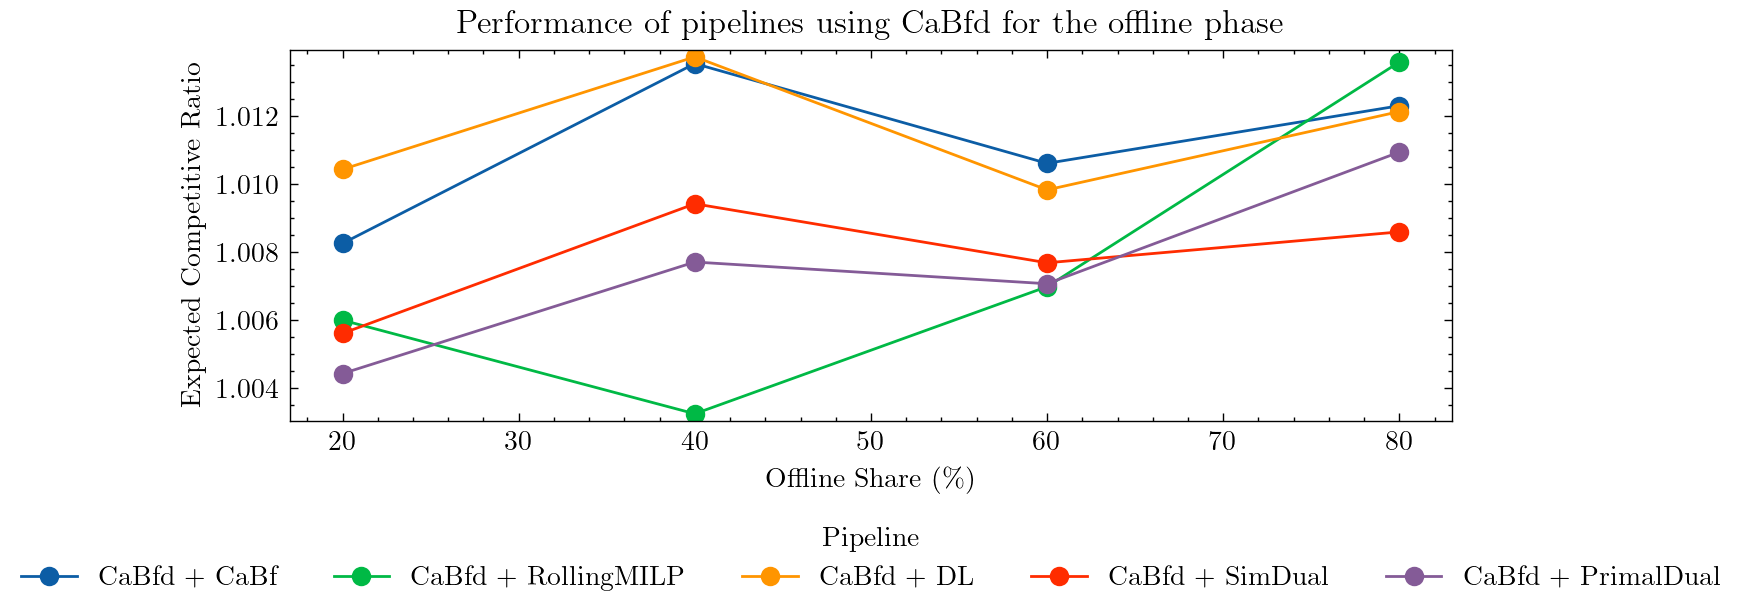

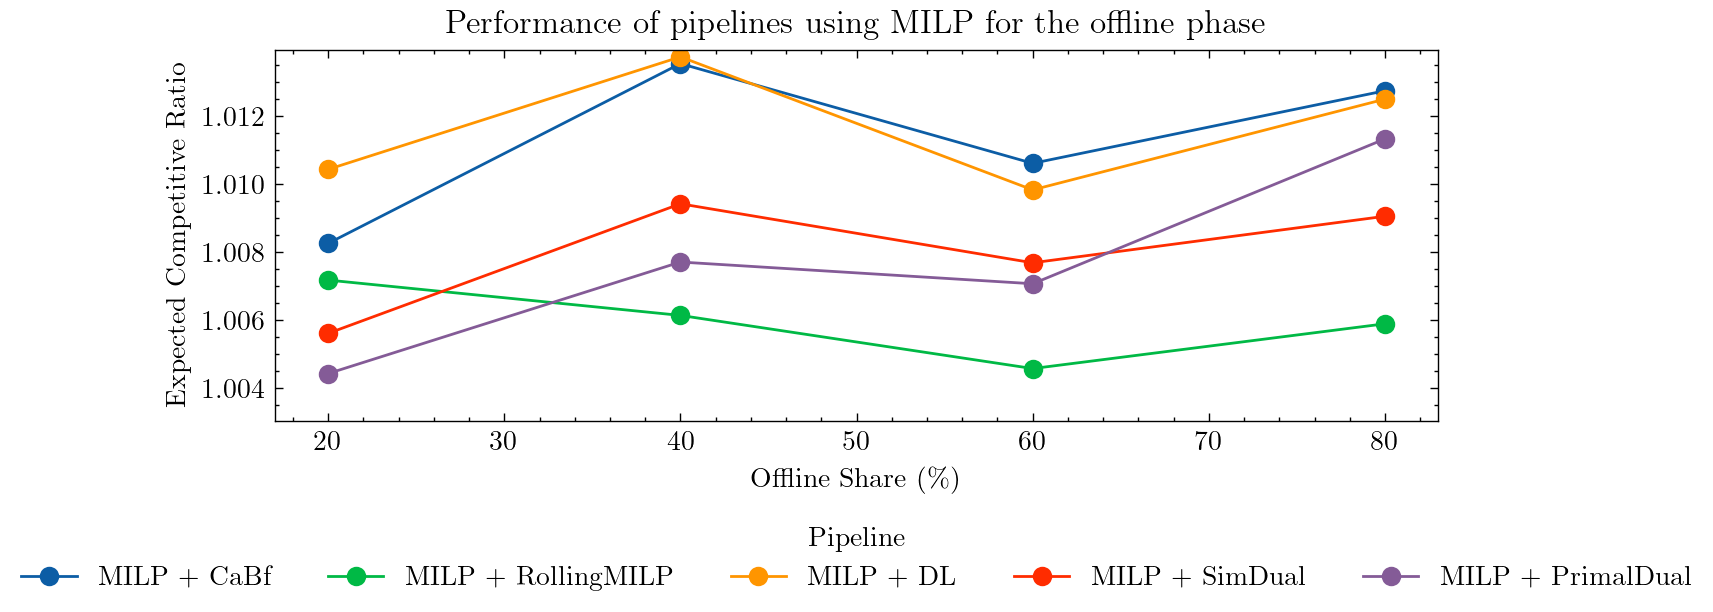

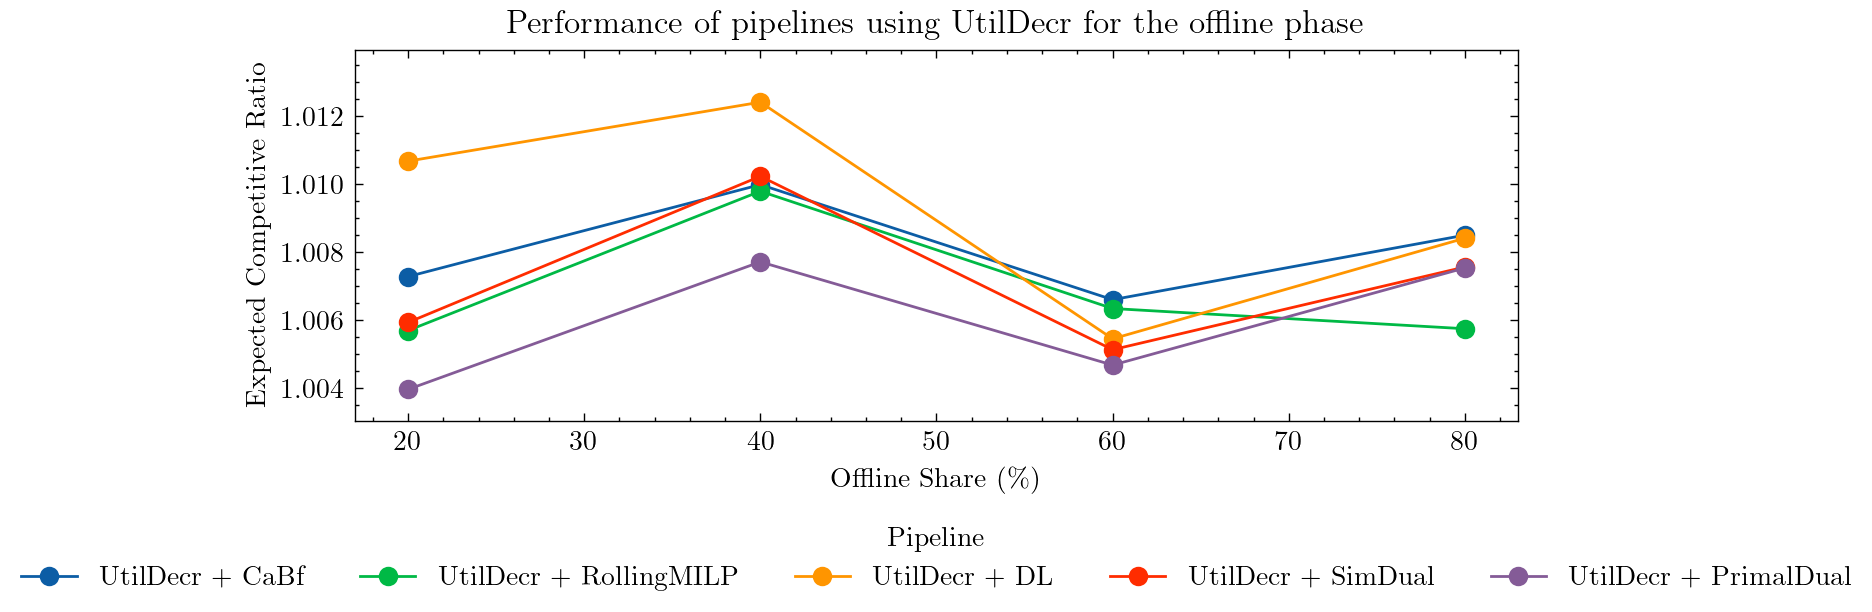

In [55]:
# Performance vs. Offline Share (per offline solver)
if df_baseline_expected is not None:
    df_plot = df_baseline_expected[
        df_baseline_expected["offline_pct"].gt(0).fillna(False)
    ].copy()

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]  # NO SIMBASE

    df_plot["offline_algorithm"] = pd.Categorical(
        df_plot["offline_algorithm"], categories=offline_order, ordered=True
    )
    df_plot["online_algorithm"] = pd.Categorical(
        df_plot["online_algorithm"], categories=online_order, ordered=True
    )
    df_plot = df_plot.sort_values(
        ["offline_algorithm", "online_algorithm", "offline_pct"]
    )

    y_min = df_plot["expected_cr"].min()
    y_max = df_plot["expected_cr"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))

    for offline in offline_order:
        df_sub = df_plot[df_plot["offline_algorithm"] == offline].copy()
        if df_sub.empty:
            continue

        df_sub["pipeline"] = (
            df_sub["offline_algorithm"].astype(str)
            + " + "
            + df_sub["online_algorithm"].astype(str)
        )

        fig, ax = plt.subplots(figsize=(7.5, 3.2))
        for pipeline, df_pipe in df_sub.groupby("pipeline", sort=False):
            ax.plot(
                df_pipe["offline_pct"],
                df_pipe["expected_cr"],
                marker="o",
                label=pipeline,
            )

        ax.set_title(f"Performance of pipelines using {offline} for the offline phase")
        ax.set_xlabel(r"Offline Share (\%)")
        ax.set_ylabel("Expected Competitive Ratio")
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ncol = max(1, df_sub["pipeline"].nunique())
        ax.legend(
            title="Pipeline",
            ncol=ncol,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.22),
        )
        fig.subplots_adjust(bottom=0.3)

        filename = f"hybrid_cr_{offline.lower()}.png"
        fig.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
        plt.show()

In [ ]:
# Combined plot: Performance vs. Offline Share (all offline solvers)
if df_baseline_expected is not None:
    df_plot = df_baseline_expected[
        df_baseline_expected["offline_pct"].gt(0).fillna(False)
    ].copy()

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]  # NO SIMBASE

    df_plot["offline_algorithm"] = pd.Categorical(
        df_plot["offline_algorithm"], categories=offline_order, ordered=True
    )
    df_plot["online_algorithm"] = pd.Categorical(
        df_plot["online_algorithm"], categories=online_order, ordered=True
    )
    df_plot = df_plot.sort_values(
        ["offline_algorithm", "online_algorithm", "offline_pct"]
    )

    y_min = df_plot["expected_cr"].min()
    y_max = df_plot["expected_cr"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))

    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4), sharey=True)
    for ax, offline in zip(axes, offline_order):
        df_sub = df_plot[df_plot["offline_algorithm"] == offline].copy()
        if df_sub.empty:
            ax.set_title(f"{offline} (no data)")
            ax.axis("off")
            continue

        for online, df_on in df_sub.groupby("online_algorithm", sort=False):
            ax.plot(
                df_on["offline_pct"],
                df_on["expected_cr"],
                marker="o",
                label=str(online),
            )

        ax.set_title(f"Offline: {offline}")
        ax.set_xlabel("Offline Share (%)")
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Expected Competitive Ratio")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Online algorithm",
        ncol=min(3, len(labels)) if labels else 1,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
    )

    fig.suptitle("Performance vs. Offline Share (all offline solvers)")
    fig.tight_layout(rect=[0, 0.05, 1, 0.92])
    fig.savefig(FIG_DIR / "hybrid_cr_all_offline.png", dpi=200, bbox_inches="tight")
    plt.show()


In [56]:
# Failure Rate Table (Hybrid)
if df_baseline_expected is not None:
    df_fail = df_baseline_expected[
        df_baseline_expected["offline_pct"].gt(0).fillna(False)
    ].copy()
    df_fail["pipeline"] = (
        df_fail["offline_algorithm"].astype(str)
        + " + "
        + df_fail["online_algorithm"].astype(str)
    )

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]  # NO SIMBASE
    pipeline_order = [f"{off} + {on}" for off in offline_order for on in online_order]

    df_fail_tbl = (
        df_fail.pivot_table(
            index="offline_pct",
            columns="pipeline",
            values="failure_rate",
            aggfunc="mean",
        )
        .reindex(columns=pipeline_order)
        .sort_index()
    )
    df_fail_tbl = (df_fail_tbl * 100.0).round(2)
    df_fail_tbl.index.name = r"Offline share (\%)"

    print("\nFailure Rates by Offline Share and Pipeline (%):")
    display(df_fail_tbl)

    # Save as LaTeX table
    latex_str = df_fail_tbl.to_latex(float_format="%.1f", na_rep="--")
    with open(FIG_DIR / "hybrid_failure_rates.tex", "w") as f:
        f.write(latex_str)
    print(f"\nSaved LaTeX table to {FIG_DIR / 'hybrid_failure_rates.tex'}")


Failure Rates by Offline Share and Pipeline (%):


pipeline,CaBfd + CaBf,CaBfd + RollingMILP,CaBfd + DL,CaBfd + SimDual,CaBfd + PrimalDual,MILP + CaBf,MILP + RollingMILP,MILP + DL,MILP + SimDual,MILP + PrimalDual,UtilDecr + CaBf,UtilDecr + RollingMILP,UtilDecr + DL,UtilDecr + SimDual,UtilDecr + PrimalDual
Offline share (\%),,,,,,,,,,,,,,,
20,30.0,36.0,16.0,26.0,2.0,30.0,54.0,16.0,26.0,2.0,30.0,52.0,18.0,20.0,4.0
40,40.0,52.0,14.0,28.0,22.0,40.0,50.0,14.0,28.0,22.0,26.0,24.0,12.0,26.0,16.0
60,32.0,56.0,22.0,14.0,30.0,32.0,68.0,22.0,14.0,30.0,20.0,42.0,20.0,16.0,20.0
80,32.0,80.0,32.0,32.0,30.0,34.0,76.0,34.0,34.0,32.0,6.0,24.0,6.0,8.0,8.0



Saved LaTeX table to figures/hybrid_failure_rates.tex


## 5. Algorithm Comparison and Synthesis\n\nStatistical testing and Pareto frontier analysis.

In [57]:
# PHASE 5: Statistical Significance Testing
if df_per_seed is not None:
    from scipy.stats import wilcoxon
    from itertools import combinations

    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    # Get purely online data
    df_online_all = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    df_online_success = df_online_all[
        ~df_online_all["offline_status"].isin(offline_fail_statuses)
        & ~df_online_all["online_status"].isin(online_fail_statuses)
    ].copy()

    # Get optimal benchmarks
    df_opt_all = df_per_seed[(df_per_seed["kind"] == "optimal") & (df_per_seed["M_off"] == 0)].copy()
    df_opt_success = df_opt_all[~df_opt_all["status"].isin(offline_fail_statuses)].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    # Merge and compute CR
    df_test = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_test = df_test[df_test["optimal_objective"].notna()]
    df_test = df_test[df_test["online_objective"].notna()]
    df_test["competitive_ratio"] = df_test["online_objective"] / df_test["optimal_objective"]

    # NO SIMBASE
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
    df_test = df_test[df_test["online_short"].isin(online_order)]

    # Perform pairwise Wilcoxon signed-rank tests
    algorithms = [algo for algo in online_order if algo in df_test["online_short"].unique()]
    p_values = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)

    pair_keys = ["sweep", "run_id", "scenario", "seed"]
    for algo1, algo2 in combinations(algorithms, 2):
        df1 = df_test[df_test["online_short"] == algo1]
        df2 = df_test[df_test["online_short"] == algo2]

        # Pair on shared (scenario, seed, run) so we compare like-for-like runs
        df_pair = df1.merge(
            df2[pair_keys + ["competitive_ratio"]],
            on=pair_keys,
            suffixes=("_1", "_2"),
            how="inner",
        )

        if len(df_pair) < 3:
            continue

        try:
            stat, pval = wilcoxon(
                df_pair["competitive_ratio_1"].values,
                df_pair["competitive_ratio_2"].values,
            )
            p_values.loc[algo1, algo2] = pval
            p_values.loc[algo2, algo1] = pval
        except Exception as e:
            print(f"Warning: Could not compute test for {algo1} vs {algo2}: {e}")

    # Diagonal is 1.0 (same algorithm)
    for algo in algorithms:
        p_values.loc[algo, algo] = 1.0

    print("\nPairwise Wilcoxon Signed-Rank Test (p-values):")
    print("Values < 0.05 indicate statistically significant difference")
    display(p_values.astype(float).round(4))

    # Highlight significant differences (p < 0.05)
    print("\nSignificant pairwise differences (p < 0.05):")
    sig_pairs = []
    for algo1, algo2 in combinations(algorithms, 2):
        pval = p_values.loc[algo1, algo2]
        if pd.notna(pval) and pval < 0.05:
            # Determine which is better
            mean1 = df_test[df_test["online_short"] == algo1]["competitive_ratio"].mean()
            mean2 = df_test[df_test["online_short"] == algo2]["competitive_ratio"].mean()
            better = algo1 if mean1 < mean2 else algo2
            sig_pairs.append({
                "Comparison": f"{algo1} vs {algo2}",
                "p-value": round(pval, 4),
                "Better": better
            })

    if sig_pairs:
        display(pd.DataFrame(sig_pairs))
    else:
        print("No significant pairwise differences found.")


Pairwise Wilcoxon Signed-Rank Test (p-values):
Values < 0.05 indicate statistically significant difference


,CaBf,RollingMILP,DL,SimDual,PrimalDual
CaBf,1.0,0.0000,0.0,0.0000,0.0
RollingMILP,0.0,1.0000,0.0,0.0001,0.0
DL,0.0,0.0000,1.0,0.0000,0.0
SimDual,0.0,0.0001,0.0,1.0000,0.0
PrimalDual,0.0,0.0000,0.0,0.0000,1.0



Significant pairwise differences (p < 0.05):


,Comparison,p-value,Better
0,CaBf vs RollingMILP,0.0000,RollingMILP
1,CaBf vs DL,0.0000,CaBf
2,CaBf vs SimDual,0.0000,SimDual
3,CaBf vs PrimalDual,0.0000,PrimalDual
4,RollingMILP vs DL,0.0000,RollingMILP
5,RollingMILP vs SimDual,0.0001,SimDual
6,RollingMILP vs PrimalDual,0.0000,PrimalDual
7,DL vs SimDual,0.0000,SimDual
8,DL vs PrimalDual,0.0000,PrimalDual
9,SimDual vs PrimalDual,0.0000,PrimalDual


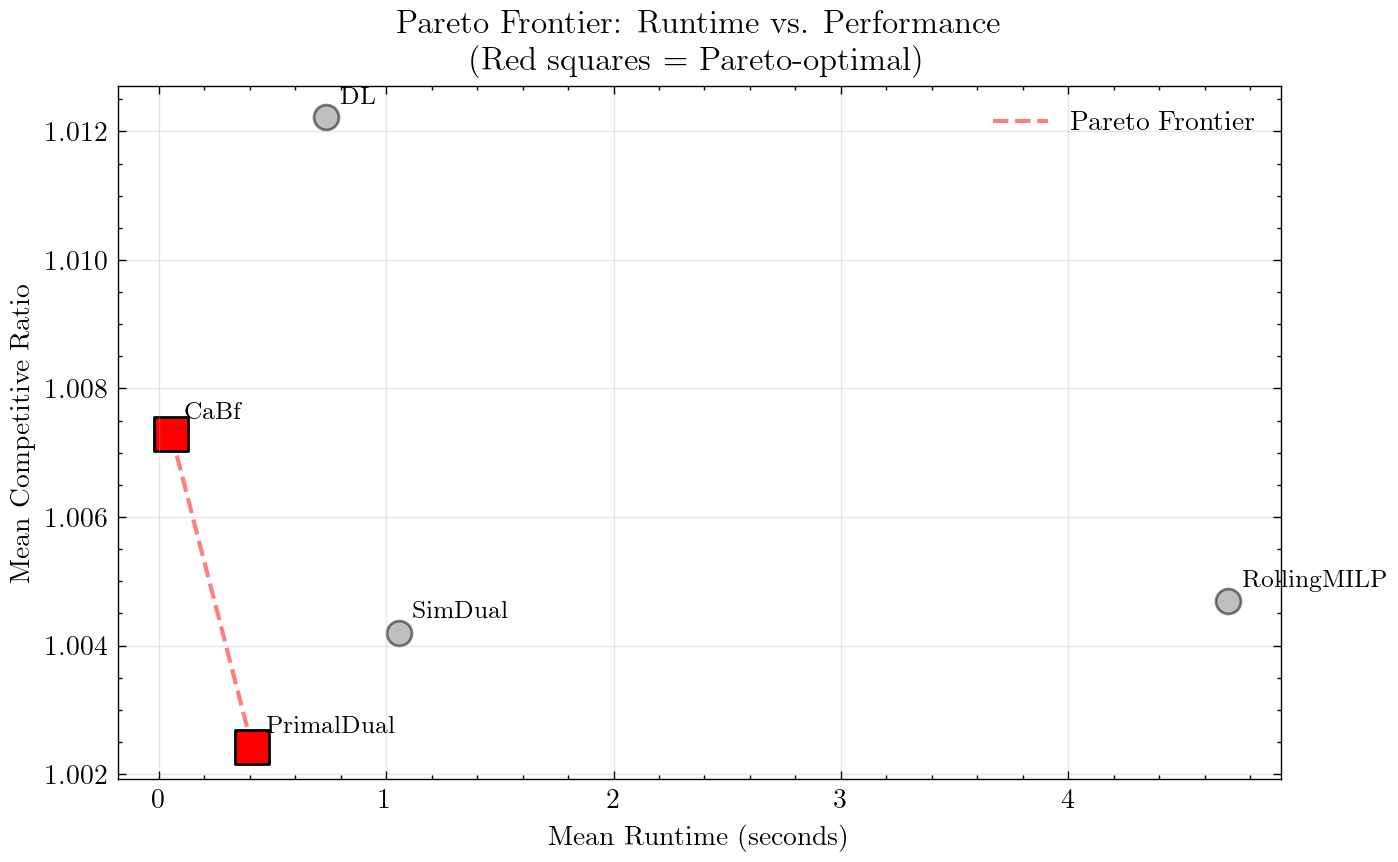


Pareto-Optimal Algorithms:


,online_short,mean_cr,mean_runtime
2,PrimalDual,1.002415,0.411385
0,CaBf,1.007291,0.055280



Dominated Algorithms:


,online_short,mean_cr,mean_runtime
4,SimDual,1.004196,1.057374
3,RollingMILP,1.004696,4.702721
1,DL,1.012218,0.737663


In [58]:
# Pareto Frontier Analysis
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    # Get purely online data
    df_online_only = df_per_seed[
        (df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)
    ].copy()

    df_online_success = df_online_only[
        ~df_online_only["offline_status"].isin(offline_fail_statuses)
        & ~df_online_only["online_status"].isin(online_fail_statuses)
    ].copy()

    # Get optimal benchmarks
    df_opt_only = df_per_seed[
        (df_per_seed["kind"] == "optimal") & (df_per_seed["M_off"] == 0)
    ].copy()
    df_opt_success = df_opt_only[
        ~df_opt_only["status"].isin(offline_fail_statuses)
    ].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    # Merge and compute CR
    df_pareto = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_pareto = df_pareto[df_pareto["optimal_objective"].notna()]
    df_pareto = df_pareto[df_pareto["online_objective"].notna()]
    df_pareto["competitive_ratio"] = df_pareto["online_objective"] / df_pareto["optimal_objective"]

    # Aggregate by algorithm
    agg = df_pareto.groupby("online_short", dropna=False).agg(
        mean_cr=("competitive_ratio", "mean"),
        mean_runtime=("online_runtime", "mean"),
    ).reset_index()

    # NO SIMBASE
    online_order = ["CaBf", "RollingMILP", "DL", "SimDual", "PrimalDual"]
    agg = agg[agg["online_short"].isin(online_order)]

    # Identify Pareto frontier (lower CR and lower runtime is better)
    def is_pareto_efficient(costs):
        """
        Find the Pareto-efficient points.
        costs: An (n_points, n_costs) array
        Returns: A boolean array indicating Pareto-efficient points
        """
        is_efficient = np.ones(costs.shape[0], dtype=bool)
        for i, c in enumerate(costs):
            if is_efficient[i]:
                # Keep points that are not dominated by this point
                is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
                is_efficient[i] = True
        return is_efficient

    if not agg.empty:
        # Prepare data for Pareto analysis (both objectives: minimize)
        costs = agg[["mean_runtime", "mean_cr"]].values
        pareto_mask = is_pareto_efficient(costs)

        fig, ax = plt.subplots(figsize=(7.5, 4.5))

        # Plot all points
        for idx, row in agg.iterrows():
            color = "red" if pareto_mask[idx] else "gray"
            marker = "s" if pareto_mask[idx] else "o"
            size = 150 if pareto_mask[idx] else 80
            alpha = 1.0 if pareto_mask[idx] else 0.5

            ax.scatter(row["mean_runtime"], row["mean_cr"],
                      color=color, marker=marker, s=size, alpha=alpha, edgecolors="black")
            ax.annotate(
                row["online_short"],
                (row["mean_runtime"], row["mean_cr"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold" if pareto_mask[idx] else "normal",
            )

        # Draw Pareto frontier line
        pareto_points = agg[pareto_mask].sort_values("mean_runtime")
        if len(pareto_points) > 1:
            ax.plot(pareto_points["mean_runtime"], pareto_points["mean_cr"],
                   'r--', alpha=0.5, linewidth=1.5, label="Pareto Frontier")

        ax.set_xlabel("Mean Runtime (seconds)")
        ax.set_ylabel("Mean Competitive Ratio")
        ax.set_title("Pareto Frontier: Runtime vs. Performance\n(Red squares = Pareto-optimal)")
        ax.grid(True, alpha=0.3)
        ax.legend()

        fig.savefig(FIG_DIR / "pareto_frontier.png", dpi=200, bbox_inches="tight")
        plt.show()

        print("\nPareto-Optimal Algorithms:")
        pareto_algos = agg[pareto_mask].sort_values("mean_cr")
        display(pareto_algos)

        print("\nDominated Algorithms:")
        dominated = agg[~pareto_mask].sort_values("mean_cr")
        if not dominated.empty:
            display(dominated)
        else:
            print("None - all algorithms are Pareto-optimal!")

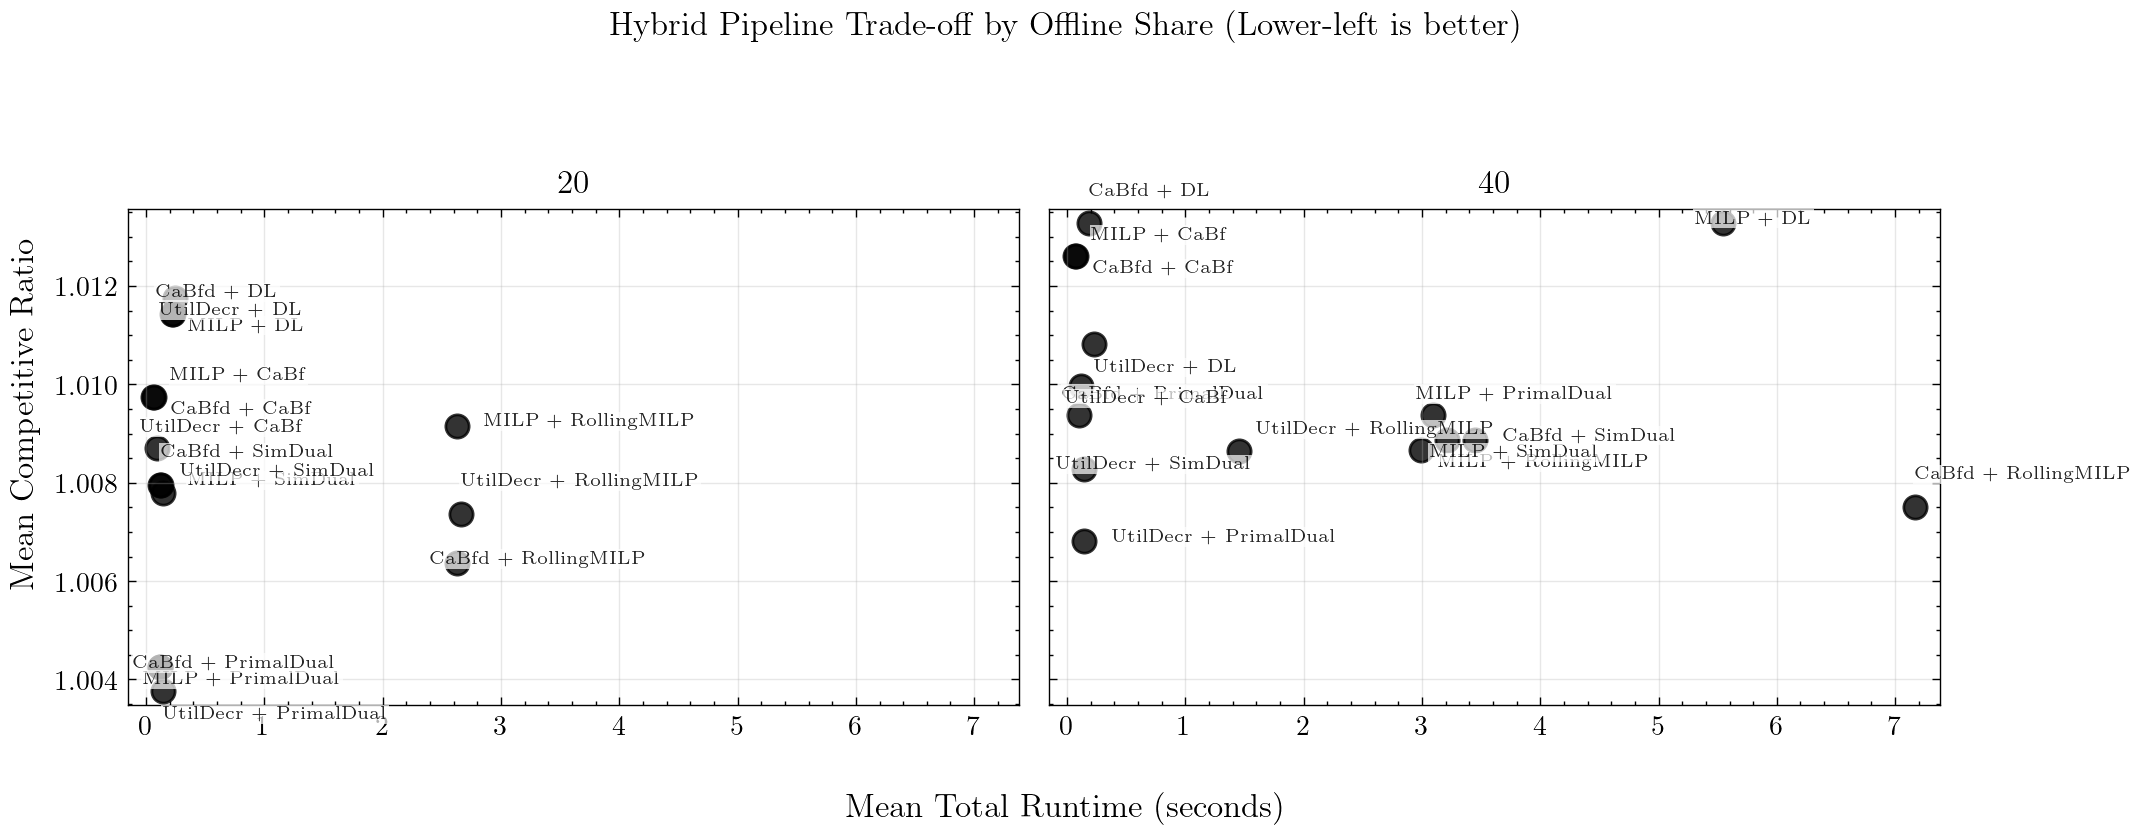

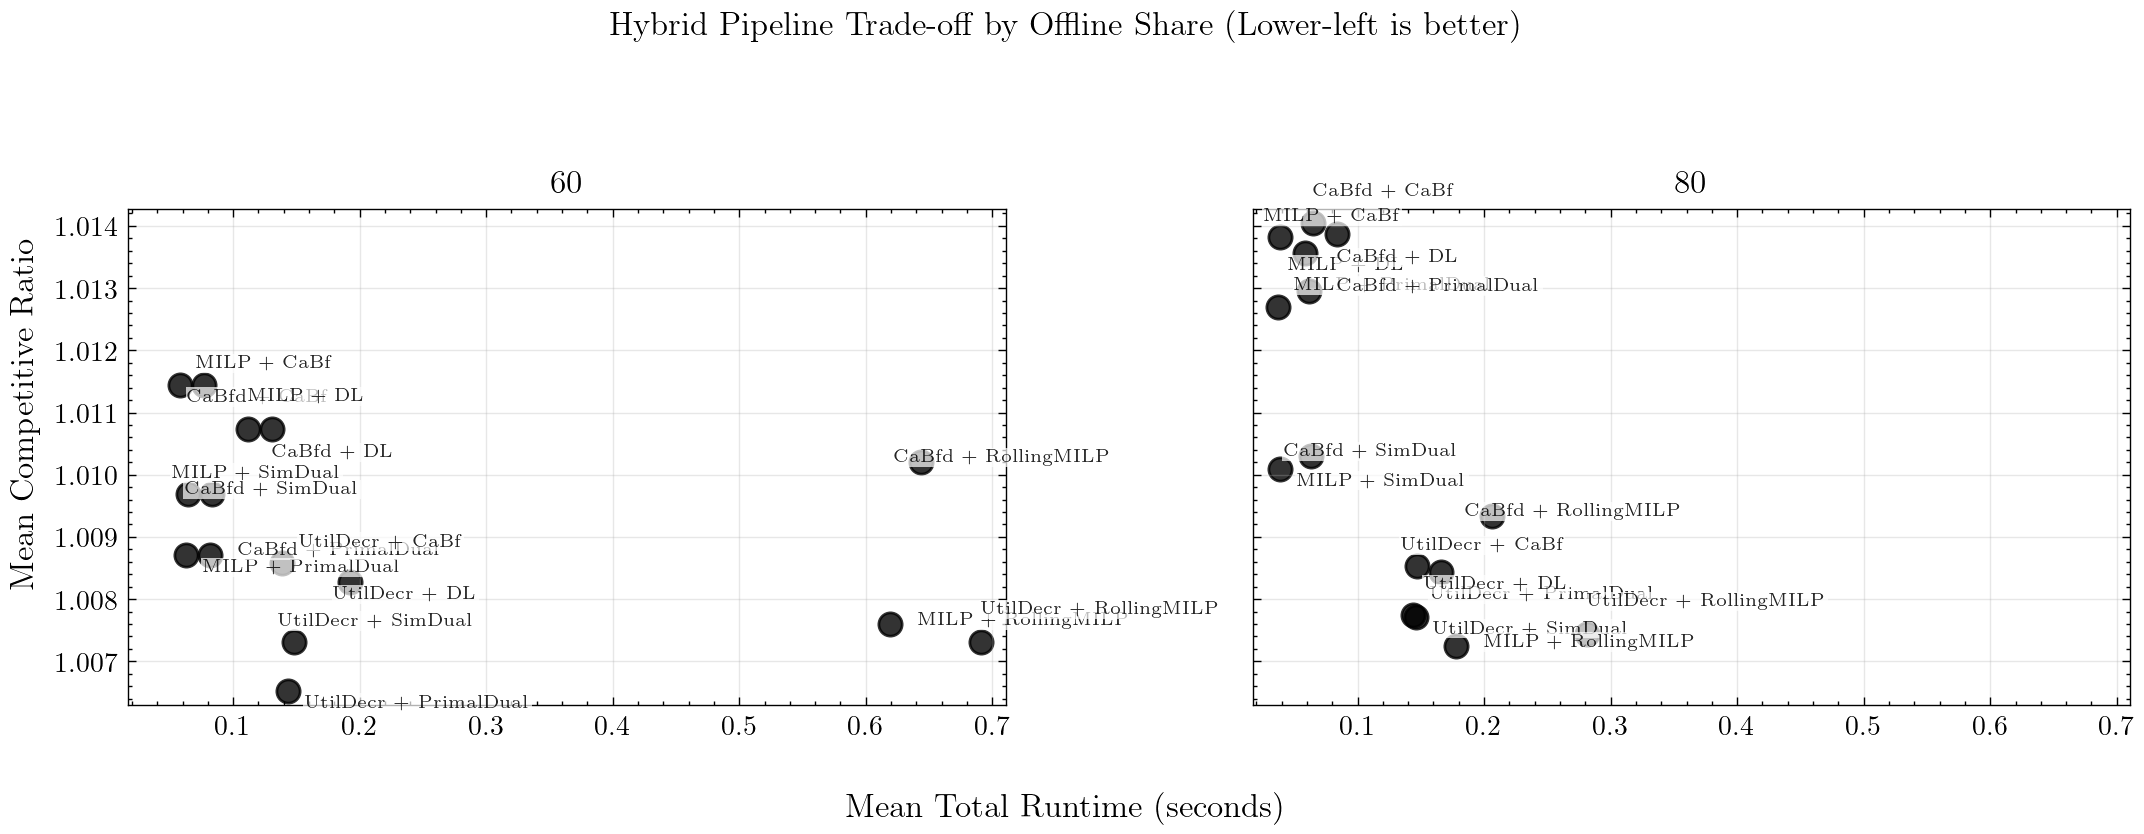


Hybrid Runtime vs. Performance (by offline share):


,pipeline,offline_pct,mean_cr,mean_runtime
61,UtilDecr + PrimalDual,20.0,1.003768,0.141327
11,CaBfd + PrimalDual,20.0,1.004243,0.121257
36,MILP + PrimalDual,20.0,1.004243,0.114702
16,CaBfd + RollingMILP,20.0,1.006360,2.631963
66,UtilDecr + RollingMILP,20.0,1.007372,2.660276
71,UtilDecr + SimDual,20.0,1.007797,0.143152
21,CaBfd + SimDual,20.0,1.007956,0.122529
46,MILP + SimDual,20.0,1.007956,0.116498
51,UtilDecr + CaBf,20.0,1.008701,0.090274
41,MILP + RollingMILP,20.0,1.009156,2.625621



Pareto-Optimal Hybrid Pipelines:


,pipeline,offline_pct,mean_cr,mean_runtime
60,UtilDecr + PrimalDual,0.0,1.002747,0.140897
36,MILP + PrimalDual,20.0,1.004243,0.114702
25,MILP + CaBf,0.0,1.008338,0.050713
49,MILP + SimDual,80.0,1.010098,0.038967
39,MILP + PrimalDual,80.0,1.012704,0.036768


In [59]:
# Hybrid Runtime-Performance Trade-off
# Analyzing complete pipelines across different offline/online splits
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    # Get baseline scenarios (all offline/online splits)
    df_hybrid = df_per_seed[
        (df_per_seed["kind"] == "eval") &
        (df_per_seed["family"] == "baseline")
    ].copy()

    df_hybrid_success = df_hybrid[
        ~df_hybrid["offline_status"].isin(offline_fail_statuses)
        & ~df_hybrid["online_status"].isin(online_fail_statuses)
    ].copy()

    # Get optimal benchmarks
    df_opt_hybrid = df_per_seed[
        (df_per_seed["kind"] == "optimal") &
        (df_per_seed["family"] == "baseline")
    ].copy()
    df_opt_success = df_opt_hybrid[
        ~df_opt_hybrid["status"].isin(offline_fail_statuses)
    ].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    # Merge and compute CR
    df_hybrid_perf = df_hybrid_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_hybrid_perf = df_hybrid_perf[df_hybrid_perf["optimal_objective"].notna()]
    df_hybrid_perf = df_hybrid_perf[df_hybrid_perf["total_objective"].notna()]
    df_hybrid_perf["competitive_ratio"] = df_hybrid_perf["total_objective"] / df_hybrid_perf["optimal_objective"]

    # Compute total runtime (offline + online)
    df_hybrid_perf["total_runtime"] = (
        df_hybrid_perf["offline_runtime"].fillna(0) +
        df_hybrid_perf["online_runtime"].fillna(0)
    )

    # Compute offline percentage
    denom = df_hybrid_perf["M_off"].fillna(0) + df_hybrid_perf["M_on"].fillna(0)
    df_hybrid_perf["offline_pct"] = (
        (df_hybrid_perf["M_off"] / denom) * 100
    ).where(denom > 0)

    # Aggregate by pipeline and offline_pct
    agg_hybrid = df_hybrid_perf.groupby(["pipeline", "offline_pct"], dropna=False).agg(
        mean_cr=("competitive_ratio", "mean"),
        mean_runtime=("total_runtime", "mean"),
        std_cr=("competitive_ratio", "std"),
        std_runtime=("total_runtime", "std"),
    ).reset_index()

    # Filter to specific offline shares for clarity (20%, 40%, 60%, 80%)
    agg_hybrid_filtered = agg_hybrid[agg_hybrid["offline_pct"].isin([20, 40, 60, 80])]

    if not agg_hybrid_filtered.empty:
        label_offsets = [(6, 6), (6, -6), (-6, 6), (-6, -6), (10, 0), (-10, 0), (0, 10), (0, -10)]

        def plot_offline_shares(fig_name, shares):
            df_shares = agg_hybrid_filtered[agg_hybrid_filtered["offline_pct"].isin(shares)]
            x_min = df_shares["mean_runtime"].min()
            x_max = df_shares["mean_runtime"].max()
            y_min = df_shares["mean_cr"].min()
            y_max = df_shares["mean_cr"].max()

            if pd.isna(x_min) or pd.isna(x_max):
                x_min, x_max = 0.0, 1.0
            if pd.isna(y_min) or pd.isna(y_max):
                y_min, y_max = 0.0, 1.0

            x_span = x_max - x_min
            y_span = y_max - y_min
            x_pad = 0.03 * x_span if x_span > 0 else 1.0
            y_pad = 0.03 * y_span if y_span > 0 else 0.02

            fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True, sharey=True)
            for ax, off_pct in zip(axes, shares):
                df_pct = agg_hybrid_filtered[agg_hybrid_filtered["offline_pct"] == off_pct]
                if df_pct.empty:
                    ax.set_title(f"{int(off_pct)}% Offline Share (no data)")
                    ax.axis("off")
                    continue

                df_pct = df_pct.sort_values(["mean_runtime", "mean_cr"]).reset_index(drop=True)
                ax.scatter(
                    df_pct["mean_runtime"],
                    df_pct["mean_cr"],
                    s=70,
                    alpha=0.8,
                    color="black",
                )

                for idx, row in df_pct.iterrows():
                    dx, dy = label_offsets[idx % len(label_offsets)]
                    ax.annotate(
                        row["pipeline"],
                        (row["mean_runtime"], row["mean_cr"]),
                        xytext=(dx, dy),
                        textcoords="offset points",
                        fontsize=6.5,
                        alpha=0.85,
                        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.6),
                    )

                ax.set_title(f"{int(off_pct)}% Offline Share")
                ax.grid(True, alpha=0.3)
                ax.set_xlim(x_min - x_pad, x_max + x_pad)
                ax.set_ylim(y_min - y_pad, y_max + y_pad)

            fig.suptitle("Hybrid Pipeline Trade-off by Offline Share (Lower-left is better)")
            fig.supxlabel("Mean Total Runtime (seconds)")
            fig.supylabel("Mean Competitive Ratio")
            fig.tight_layout(rect=[0, 0, 1, 0.9])

            fig.savefig(FIG_DIR / fig_name, dpi=200, bbox_inches="tight")
            plt.show()

        plot_offline_shares("hybrid_runtime_vs_performance_20_40.png", [20, 40])
        plot_offline_shares("hybrid_runtime_vs_performance_60_80.png", [60, 80])

        print("\nHybrid Runtime vs. Performance (by offline share):")
        summary = agg_hybrid_filtered.sort_values(["offline_pct", "mean_cr"])
        display(summary[["pipeline", "offline_pct", "mean_cr", "mean_runtime"]].head(20))

        # Identify Pareto-optimal pipelines (across ALL offline shares)
        def is_pareto_efficient(costs):
            is_efficient = np.ones(costs.shape[0], dtype=bool)
            for i, c in enumerate(costs):
                if is_efficient[i]:
                    is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
                    is_efficient[i] = True
            return is_efficient

        costs = agg_hybrid[["mean_runtime", "mean_cr"]].values
        pareto_mask = is_pareto_efficient(costs)

        print("\nPareto-Optimal Hybrid Pipelines:")
        pareto_pipelines = agg_hybrid[pareto_mask].sort_values("mean_cr")
        display(pareto_pipelines[["pipeline", "offline_pct", "mean_cr", "mean_runtime"]])